# ✈️ Temporal EDA — Flight Delay Prediction (2018–2024)
**Objective:** Understand how delay seasonality evolves across years along every temporal dimension available in `bts_merged` flight and weather data.

In [ ]:
# ── Run this cell FIRST ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import time
import os
import requests
from io import StringIO
import pyarrow.parquet as pq
import pyarrow as pa

# For Jupyter notebooks — render plots inline
%matplotlib inline

print("✅ All imports successful!")

✅ All imports successful!


# Read in the data

In [ ]:
import pandas as pd

df = pd.read_parquet("data/flights_2018_2024_v2.parquet")

df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0.0,220.0,1670.0,7
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0.0,207.0,1222.0,5
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0.0,267.0,1635.0,7
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0.0,147.0,966.0,4
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0.0,188.0,1303.0,6


In [ ]:
df.shape      # total rows and columns

(45968068, 17)

In [ ]:
df["Year"].unique()   # years present

array([2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [ ]:
summary = df.groupby("Year").size().to_frame("rows")
summary["columns"] = df.shape[1]

print(summary)

         rows  columns
Year                  
2018  7206195       17
2019  7422037       17
2020  4688354       17
2021  5995397       17
2022  6729125       17
2023  6847899       17
2024  7079061       17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   FlightDate                       object 
 6   Reporting_Airline                object 
 7   Flight_Number_Reporting_Airline  float64
 8   Origin                           object 
 9   Dest                             object 
 10  CRSDepTime                       int64  
 11  DepTimeBlk                       object 
 12  CRSArrTime                       int64  
 13  ArrDel15                         float64
 14  CRSElapsedTime                   float64
 15  Distance                         float64
 16  DistanceGroup                    int64  
dtypes: flo

## Convert columns to other data types

In [ ]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

cat_cols = ["Reporting_Airline", "Origin", "Dest", "DepTimeBlk"]
df[cat_cols] = df[cat_cols].astype("category")

df["Flight_Number_Reporting_Airline"] = df["Flight_Number_Reporting_Airline"].astype("string")

df["ArrDel15"] = df["ArrDel15"].astype("Int64")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Year                             int64         
 1   Quarter                          int64         
 2   Month                            int64         
 3   DayofMonth                       int64         
 4   DayOfWeek                        int64         
 5   FlightDate                       datetime64[ns]
 6   Reporting_Airline                category      
 7   Flight_Number_Reporting_Airline  string        
 8   Origin                           category      
 9   Dest                             category      
 10  CRSDepTime                       int64         
 11  DepTimeBlk                       category      
 12  CRSArrTime                       int64         
 13  ArrDel15                         Int64         
 14  CRSElapsedTime                  

## Missingness Analysis

In [ ]:
import pandas as pd
import numpy as np

def missing_value_analysis(df: pd.DataFrame, show_all: bool = False) -> pd.DataFrame:
    # --- Basic counts ---
    total_rows = len(df)
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / total_rows) * 100
    present_count = df.notnull().sum()
    dtype_series = df.dtypes

    # --- Build summary table ---
    summary = pd.DataFrame({
        'dtype': dtype_series,
        'total_rows': total_rows,
        'missing_count': missing_count,
        'missing_pct': missing_pct.round(2),
        'present_count': present_count,
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)

    if not show_all:
        summary = summary[summary['missing_count'] > 0]

    # --- Print high-level overview ---
    total_cells = np.prod(df.shape)
    total_missing = df.isnull().sum().sum()
    cols_with_missing = (missing_count > 0).sum()

    print("=" * 55)
    print("       MISSING VALUE ANALYSIS REPORT")
    print("=" * 55)
    print(f"  📐 Shape              : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  🔢 Total cells        : {total_cells:,}")
    print(f"  ❌ Total missing      : {total_missing:,} ({total_missing/total_cells*100:.2f}%)")
    print(f"  📋 Columns w/ missing : {cols_with_missing} / {df.shape[1]}")
    print(f"  ✅ Complete rows       : {df.dropna().shape[0]:,} / {df.shape[0]:,}")
    print("=" * 55)

    return summary

def missing_pattern_analysis(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Identify co-occurrence patterns of missing values.

    Shows which combinations of columns tend to be missing together.
    """
    # Encode each row's missing pattern as a string signature
    pattern = df.isnull().astype(int)
    cols = df.columns.tolist()

    pattern['_signature'] = pattern.apply(
        lambda row: ' | '.join([c for c, v in zip(cols, row) if v == 1]) or '✅ No missing',
        axis=1
    )

    pattern_counts = (
        pattern['_signature']
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    pattern_counts.columns = ['missing_columns_pattern', 'row_count']
    pattern_counts['pct_of_rows'] = (pattern_counts['row_count'] / len(df) * 100).round(2)

    print(f"\n🔍 Top {top_n} Missing Value Patterns:\n")
    return pattern_counts

In [ ]:
# Run the main analysis
summary = missing_value_analysis(df, show_all=True)
print(summary)

# View co-occurrence patterns
patterns = missing_pattern_analysis(df)
print(patterns)

       MISSING VALUE ANALYSIS REPORT
  📐 Shape              : 45968068 rows × 17 columns
  🔢 Total cells        : 781,457,156
  ❌ Total missing      : 1,110,074 (0.14%)
  📋 Columns w/ missing : 3 / 17
  ✅ Complete rows       : 44,858,151 / 45,968,068
                                          dtype  total_rows  missing_count  \
ArrDel15                                  Int64    45968068        1109916   
Year                                      int64    45968068              0   
Dest                                   category    45968068              0   
Distance                                float64    45968068              0   
CRSElapsedTime                          float64    45968068            157   
CRSArrTime                                int64    45968068              0   
DepTimeBlk                             category    45968068              0   
CRSDepTime                                int64    45968068              0   
Origin                                 category

## Distribution of ArrDelay15

In [ ]:
# Summary statistics
print("\n📊 ArrDel15 Summary Statistics")
print(df["ArrDel15"].describe().round(2))


📊 ArrDel15 Summary Statistics
count    44858152.0
mean           0.19
std            0.39
min             0.0
25%             0.0
50%             0.0
75%             0.0
max             1.0
Name: ArrDel15, dtype: Float64


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Arrival Delay Summary Statistics by Year
# ══════════════════════════════════════════════════════════════════════

yearly_stats = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Count    = "count",
          Mean     = "mean"
      )
      .round(2)
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 90)
print("✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR")
print("=" * 90)
print(yearly_stats.to_string())
print("-" * 90)

# ── Overall across all years ──────────────────────────────────────────
print("\n📌 OVERALL (All Years Combined)")
print(f"   Count       : {df['ArrDel15'].count():,}")
print(f"   Mean        : {df['ArrDel15'].mean():.2f}")

✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR
        Count  Mean
Year               
2018  7071464  0.19
2019  7268232  0.19
2020  4399575   0.1
2021  5878219  0.17
2022  6532012  0.21
2023  6743403  0.21
2024  6965247  0.21
------------------------------------------------------------------------------------------

📌 OVERALL (All Years Combined)
   Count       : 44,858,152
   Mean        : 0.19


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Class Imbalance Ratio by Year
# ══════════════════════════════════════════════════════════════════════

imbalance = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Total_Flights = "count",
          Delayed       = "sum",                              # class 1
      )
      .assign(
          On_Time         = lambda x: x["Total_Flights"] - x["Delayed"],   # class 0
          Delayed_Pct     = lambda x: (x["Delayed"] / x["Total_Flights"] * 100).round(2),
          On_Time_Pct     = lambda x: (x["On_Time"] / x["Total_Flights"] * 100).round(2),
          Imbalance_Ratio = lambda x: (x["On_Time"] / x["Delayed"]).round(2)  # majority / minority
      )
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 95)
print("✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)")
print("=" * 95)
print(imbalance.to_string())
print("-" * 95)

# ── Overall ───────────────────────────────────────────────────────────
total    = len(df)
delayed  = df["ArrDel15"].sum()
on_time  = total - delayed
ratio    = round(on_time / delayed, 2)

print(f"\n📌 OVERALL")
print(f"   Total Flights    : {total:,}")
print(f"   On-Time (class 0): {on_time:,}  ({on_time/total*100:.2f}%)")
print(f"   Delayed (class 1): {delayed:,}  ({delayed/total*100:.2f}%)")
print(f"   Imbalance Ratio  : {ratio} : 1")

✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)
      Total_Flights  Delayed  On_Time  Delayed_Pct  On_Time_Pct  Imbalance_Ratio
Year                                                                            
2018        7071464  1352165  5719299        19.12        80.88             4.23
2019        7268232  1389253  5878979        19.11        80.89             4.23
2020        4399575   431921  3967654         9.82        90.18             9.19
2021        5878219  1010332  4867887        17.19        82.81             4.82
2022        6532012  1376798  5155214        21.08        78.92             3.74
2023        6743403  1386699  5356704        20.56        79.44             3.86
2024        6965247  1449966  5515281        20.82        79.18              3.8
-----------------------------------------------------------------------------------------------

📌 OVERALL
   Total Flights    : 45,968,068
   On-Time (class 0): 37,570,934  (81.73%)
   Delayed (class 1): 8,

Delayed flights constitute ~18/.27% of the data, with imbalance increasing during COVID. Several post‑arrival fields are excluded to prevent leakage.

   Year  Pct_Delayed
0  2018        19.12
1  2019        19.11
2  2020         9.82
3  2021        17.19
4  2022        21.08
5  2023        20.56
6  2024        20.82


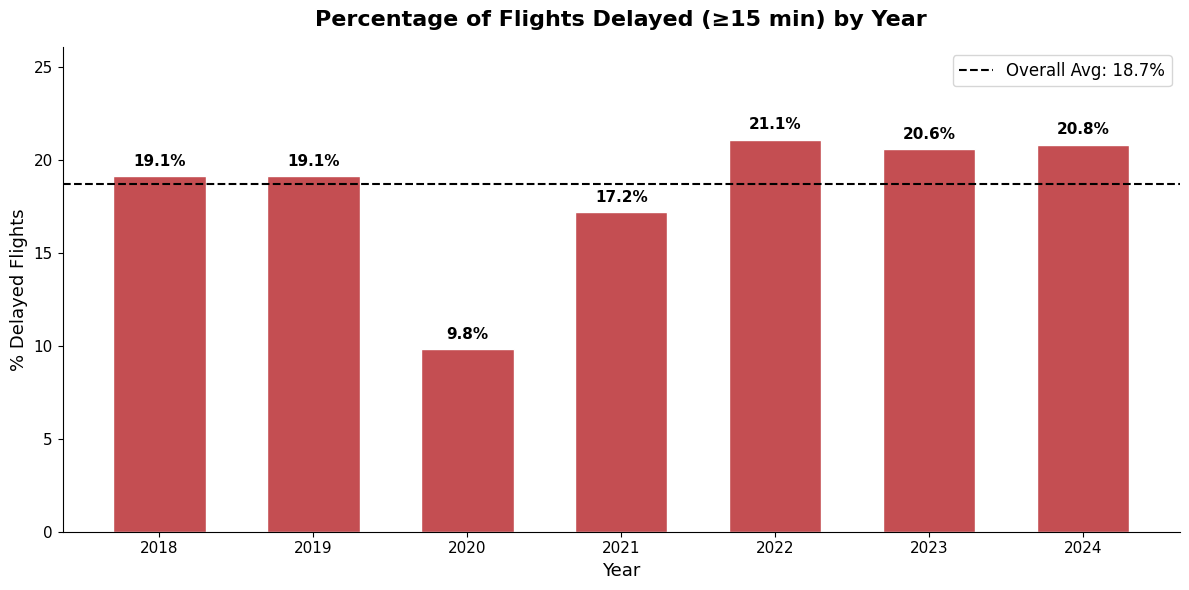

In [ ]:
# ── Calculate % Delayed by Year ──────────────────────────────────────
delay_pct = (
    df.groupby("Year")["ArrDel15"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"ArrDel15": "Pct_Delayed"})
)

print(delay_pct)

# ══════════════════════════════════════════════════════════════════════
# Bar Chart
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    delay_pct["Year"].astype(str),
    delay_pct["Pct_Delayed"],
    color="#c44e52",
    edgecolor="white",
    width=0.6
)

# ── Add value labels on top of each bar ──────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ── Add a horizontal reference line at the overall average ───────────
overall_avg = df["ArrDel15"].mean() * 100
ax.axhline(
    y=overall_avg,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Avg: {overall_avg:.1f}%"
)

# ── Formatting ───────────────────────────────────────────────────────
ax.set_title("Percentage of Flights Delayed (≥15 min) by Year",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% Delayed Flights", fontsize=13)
ax.set_ylim(0, delay_pct["Pct_Delayed"].max() + 5)
ax.legend(fontsize=12, loc="upper right")
ax.tick_params(axis="both", labelsize=11)

# Remove top & right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("delay_pct_by_year.png", dpi=150, bbox_inches="tight")
plt.show()


# Bring in weather data

In [ ]:
# Get all unique airport codes (both origin and destination)
airports = sorted(set(df['Origin'].unique()) | set(df['Dest'].unique()))
print(f"Total unique airports: {len(airports)}")
print(airports[:10])  # Preview

Total unique airports: 384
['ABE', 'ABI', 'ABQ', 'ABR', 'ABY', 'ACK', 'ACT', 'ACV', 'ACY', 'ADK']


In [ ]:
# Copy of bts data from df into bts
bts = df

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================
YEARS        = list(range(2018, 2025))     # 2018, 2019, ... 2024
TIMEZONE     = 'America/New_York'
SAVE_DIR     = 'weather_cache'
DELAY        = 5
OUTPUT_FILE  = 'bts_with_weather.parquet'

total_jobs = len(airports) * len(YEARS)
print(f"📋 BTS records:     {len(bts):,}")
print(f"✈️  Unique airports: {len(airports)}")
print(f"📅 Years:           {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} years)")
print(f"📦 Total downloads: {len(airports)} airports × {len(YEARS)} years = {total_jobs}")
print(f"⏱️  Estimated time:  ~{(total_jobs * DELAY) // 60} minutes (first run)")
print()

📋 BTS records:     45,968,068
✈️  Unique airports: 384
📅 Years:           2018–2024 (7 years)
📦 Total downloads: 384 airports × 7 years = 2688
⏱️  Estimated time:  ~224 minutes (first run)



In [ ]:
# ============================================================
# STEP 1: Download function with retry logic
# ============================================================
def fetch_weather(station, year, max_retries=3):
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        f"station={station}&"
        "data=tmpf&data=dwpf&data=relh&data=sknt&data=gust&"
        "data=vsby&data=p01i&data=wxcodes&data=feel&"
        f"tz={TIMEZONE}&"
        "format=onlycomma&latlon=no&missing=empty&"
        "trace=0.0001&"
        f"year1={year}&month1=1&day1=1&"
        f"year2={year}&month2=12&day2=31"
    )

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 429:
                wait_time = (attempt + 1) * 30
                print(f"    ⏳ 429 Rate limited. Waiting {wait_time}s "
                      f"(attempt {attempt + 1}/{max_retries})...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()

            df = pd.read_csv(StringIO(response.text))
            if len(df) > 0:
                return df
            return None

        except requests.exceptions.RequestException as e:
            wait_time = (attempt + 1) * 15
            print(f"    ⚠️ Error: {e}. Retrying in {wait_time}s...")
            time.sleep(wait_time)

    return None

In [ ]:
# ============================================================
# STEP 2: Download weather — one file per airport per year
# ============================================================
print("=" * 60)
print("DOWNLOADING WEATHER DATA")
print("=" * 60)

os.makedirs(SAVE_DIR, exist_ok=True)

all_weather = []
failed_jobs = []
job_num = 0

for year in YEARS:
    print(f"\n--- {year} ---")

    for i, airport in enumerate(airports, 1):
        job_num += 1
        cache_file = os.path.join(SAVE_DIR, f"{airport}_{year}.csv")

        # Load from cache if already downloaded
        if os.path.exists(cache_file):
            df = pd.read_csv(cache_file)
            all_weather.append(df)
            print(f"  [{job_num}/{total_jobs}] 📁 {airport} {year}: "
                  f"Cache ({len(df):,} records)")
            continue

        # Download fresh
        print(f"  [{job_num}/{total_jobs}] ⬇️  {airport} {year}...", end=" ")
        df = fetch_weather(airport, year, max_retries=3)

        if df is not None:
            df.to_csv(cache_file, index=False)
            all_weather.append(df)
            print(f"✅ {len(df):,} records")
        else:
            failed_jobs.append((airport, year))
            print("❌ No data")

        time.sleep(DELAY)

print(f"\n  ✅ Downloaded: {total_jobs - len(failed_jobs)}/{total_jobs}")
print()

DOWNLOADING WEATHER DATA

--- 2018 ---
  [1/2688] ⬇️  ABE 2018... ✅ 114,637 records
  [2/2688] ⬇️  ABI 2018... ✅ 113,695 records
  [3/2688] ⬇️  ABQ 2018... ✅ 112,889 records
  [4/2688] ⬇️  ABR 2018... ✅ 112,091 records
  [5/2688] ⬇️  ABY 2018... ✅ 112,809 records
  [6/2688] ⬇️  ACK 2018... ✅ 113,289 records
  [7/2688] ⬇️  ACT 2018... ✅ 114,773 records
  [8/2688] ⬇️  ACV 2018... ✅ 116,620 records
  [9/2688] ⬇️  ACY 2018... ✅ 115,291 records
  [10/2688] ⬇️  ADK 2018... ❌ No data
  [11/2688] ⬇️  ADQ 2018... ❌ No data
  [12/2688] ⬇️  AEX 2018... ✅ 113,762 records
  [13/2688] ⬇️  AGS 2018... ✅ 114,756 records
  [14/2688] ⬇️  AKN 2018... ❌ No data
  [15/2688] ⬇️  ALB 2018... ✅ 99,582 records
  [16/2688] ⬇️  ALO 2018... ✅ 114,552 records
  [17/2688] ⬇️  ALS 2018... ✅ 112,858 records
  [18/2688] ⬇️  ALW 2018... ✅ 108,883 records
  [19/2688] ⬇️  AMA 2018... ✅ 113,678 records
  [20/2688] ⬇️  ANC 2018... ❌ No data
  [21/2688] ⬇️  APN 2018... ✅ 112,351 records
  [22/2688] ⬇️  ART 2018... ✅ 100,234

In [ ]:
# ============================================================
# STEP 3: Retry failed stations with ICAO prefix
# ============================================================
if failed_jobs:
    print("=" * 60)
    print(f"RETRYING {len(failed_jobs)} FAILED DOWNLOADS")
    print("=" * 60)

    still_failed = []

    for airport, year in failed_jobs:
        cache_file = os.path.join(SAVE_DIR, f"{airport}_{year}.csv")
        print(f"  🔄 Retrying {airport} {year} as K{airport}...", end=" ")
        time.sleep(10)

        df = fetch_weather(f"K{airport}", year, max_retries=3)

        if df is not None:
            df['station'] = airport
            df.to_csv(cache_file, index=False)
            all_weather.append(df)
            print(f"✅ Recovered ({len(df):,} records)")
        else:
            still_failed.append((airport, year))
            print("❌ Permanently failed")

    if still_failed:
        failed_airports = sorted(set(a for a, y in still_failed))
        print(f"\n  ⛔ No data available for: {failed_airports}")
        print(f"     Total failed airport-year combos: {len(still_failed)}")
    print()
else:
    still_failed = []
    print("No failed downloads — skipping retry step 🎉\n")

RETRYING 295 FAILED DOWNLOADS
  🔄 Retrying ADK 2018 as KADK... ❌ Permanently failed
  🔄 Retrying ADQ 2018 as KADQ... ❌ Permanently failed
  🔄 Retrying AKN 2018 as KAKN... ❌ Permanently failed
  🔄 Retrying ANC 2018 as KANC... ❌ Permanently failed
  🔄 Retrying AZA 2018 as KAZA... ❌ Permanently failed
  🔄 Retrying BET 2018 as KBET... ❌ Permanently failed
  🔄 Retrying BKG 2018 as KBKG... ❌ Permanently failed
  🔄 Retrying BQN 2018 as KBQN... ❌ Permanently failed
  🔄 Retrying BRW 2018 as KBRW... ❌ Permanently failed
  🔄 Retrying CDB 2018 as KCDB... ❌ Permanently failed
  🔄 Retrying CDV 2018 as KCDV... ❌ Permanently failed
  🔄 Retrying DLG 2018 as KDLG... ❌ Permanently failed
  🔄 Retrying FAI 2018 as KFAI... ❌ Permanently failed
  🔄 Retrying FCA 2018 as KFCA... ❌ Permanently failed
  🔄 Retrying GST 2018 as KGST... ❌ Permanently failed
  🔄 Retrying GUM 2018 as KGUM... ❌ Permanently failed
  🔄 Retrying HHH 2018 as KHHH... ❌ Permanently failed
  🔄 Retrying HNL 2018 as KHNL... ❌ Permanently faile

In [ ]:
# ============================================================
# STEP 4: Combine and clean weather data
# ============================================================
print("=" * 60)
print("CLEANING WEATHER DATA")
print("=" * 60)

weather_all = pd.concat(all_weather, ignore_index=True)
print(f"  Raw records: {len(weather_all):,}")

weather_all['valid'] = pd.to_datetime(weather_all['valid'])
weather_all['date']  = weather_all['valid'].dt.date.astype(str)
weather_all['hour']  = weather_all['valid'].dt.hour

numeric_cols = ['tmpf', 'dwpf', 'relh', 'sknt', 'gust', 'vsby', 'p01i', 'feel']
for col in numeric_cols:
    if col in weather_all.columns:
        weather_all[col] = pd.to_numeric(weather_all[col], errors='coerce')

weather_hourly = weather_all.groupby(['station', 'date', 'hour']).agg(
    temp_f       = ('tmpf', 'mean'),
    dewpoint_f   = ('dwpf', 'mean'),
    humidity     = ('relh', 'mean'),
    feels_like_f = ('feel', 'mean'),
    wind_kts     = ('sknt', 'mean'),
    gust_kts     = ('gust', 'max'),
    visibility   = ('vsby', 'mean'),
    precip_in    = ('p01i', 'sum'),
    wx_codes     = ('wxcodes', lambda x: '|'.join(x.dropna().unique())),
).reset_index()

print(f"  Hourly records: {len(weather_hourly):,}")
print(f"  Stations: {weather_hourly['station'].nunique()}")
print(f"  Date range: {weather_hourly['date'].min()} → {weather_hourly['date'].max()}")
print()


CLEANING WEATHER DATA
  Raw records: 247,464,145
  Hourly records: 20,842,501
  Stations: 343
  Date range: 2018-01-01 → 2024-12-30



In [ ]:
# ============================================================
# STEP 5: Engineer weather features
# ============================================================
print("=" * 60)
print("ENGINEERING WEATHER FEATURES")
print("=" * 60)

weather_hourly['is_rain'] = weather_hourly['wx_codes'].str.contains(
    'RA|DZ|TS', case=False, na=False).astype(int)

weather_hourly['is_snow'] = weather_hourly['wx_codes'].str.contains(
    'SN|SG|PL|IC', case=False, na=False).astype(int)

weather_hourly['is_fog'] = weather_hourly['wx_codes'].str.contains(
    'FG|BR|HZ', case=False, na=False).astype(int)

weather_hourly['low_visibility'] = (
    weather_hourly['visibility'] < 3).astype(int)

weather_hourly['high_wind'] = (
    weather_hourly['gust_kts'] > 25).astype(int)

weather_hourly['severe_weather'] = (
    weather_hourly['is_rain']        |
    weather_hourly['is_snow']        |
    weather_hourly['low_visibility'] |
    weather_hourly['high_wind']
).astype(int)

weather_hourly.to_parquet('weather_hourly_all_airports.parquet', index=False)

print("  ✅ Features: is_rain, is_snow, is_fog, "
      "low_visibility, high_wind, severe_weather")
print("  💾 Saved: weather_hourly_all_airports.parquet")
print()


ENGINEERING WEATHER FEATURES
  ✅ Features: is_rain, is_snow, is_fog, low_visibility, high_wind, severe_weather
  💾 Saved: weather_hourly_all_airports.parquet



In [ ]:
bts.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Flight_Number_Reporting_Airline', 'Origin',
       'Dest', 'CRSDepTime', 'DepTimeBlk', 'CRSArrTime', 'ArrDel15',
       'CRSElapsedTime', 'Distance', 'DistanceGroup'],
      dtype='object')

In [ ]:
# ============================================================
# LOAD SAVED WEATHER DATA
# ============================================================
print("Loading saved weather data...")

weather_hourly = pd.read_parquet('weather_hourly_all_airports.parquet')

print(f"  ✅ Loaded: {len(weather_hourly):,} hourly records")
print(f"  Stations: {weather_hourly['station'].nunique()}")
print(f"  Date range: {weather_hourly['date'].min()} → {weather_hourly['date'].max()}")
print(f"  Columns: {list(weather_hourly.columns)}")
print()

OUTPUT_FILE = 'bts_with_weather.parquet'

Loading saved weather data...
  ✅ Loaded: 20,842,501 hourly records
  Stations: 343
  Date range: 2018-01-01 → 2024-12-30
  Columns: ['station', 'date', 'hour', 'temp_f', 'dewpoint_f', 'humidity', 'feels_like_f', 'wind_kts', 'gust_kts', 'visibility', 'precip_in', 'wx_codes', 'is_rain', 'is_snow', 'is_fog', 'low_visibility', 'high_wind', 'severe_weather']



In [ ]:
# ============================================================
# STEP 6: Prepare BTS join keys
# ============================================================
print("=" * 60)
print("STEP 6: PREPARING BTS MERGE KEYS")
print("=" * 60)

bts['FlightDate']  = pd.to_datetime(bts['FlightDate'])
bts['date']        = bts['FlightDate'].dt.date.astype(str)
bts['dep_hour']    = (bts['CRSDepTime'] // 100).astype('Int64')
bts['arr_hour']    = (bts['CRSArrTime'] // 100).astype('Int64')

# ── New columns: scheduled times minus 2 hours (clamped to 0–23) ──
bts['dep_hour_minus2'] = ((bts['dep_hour'] - 2) % 24).astype('Int64')
bts['arr_hour_minus2'] = ((bts['arr_hour'] - 2) % 24).astype('Int64')

print(f"  BTS records:  {len(bts):,}")
print(f"  Date range:   {bts['FlightDate'].min()} → {bts['FlightDate'].max()}")
print(f"  dep_hour sample (orig → -2h): "
      f"{bts['dep_hour'].iloc[0]} → {bts['dep_hour_minus2'].iloc[0]}")
print(f"  arr_hour sample (orig → -2h): "
      f"{bts['arr_hour'].iloc[0]} → {bts['arr_hour_minus2'].iloc[0]}")
print()

STEP 6: PREPARING BTS MERGE KEYS
  BTS records:  45,968,068
  Date range:   2018-01-01 00:00:00 → 2024-12-31 00:00:00
  dep_hour sample (orig → -2h): 7 → 5
  arr_hour sample (orig → -2h): 13 → 11



In [ ]:
# ============================================================
# STEP 7: Merge ORIGIN weather
# ============================================================
print("=" * 60)
print("STEP 7: MERGING ORIGIN WEATHER")
print("=" * 60)

origin_wx = weather_hourly.copy()
origin_wx.columns = ['station', 'date', 'hour'] + \
    [f'origin_{c}' for c in origin_wx.columns[3:]]

bts_merged = bts.merge(
    origin_wx,
    left_on  = ['Origin', 'date', 'dep_hour_minus2'],
    right_on = ['station', 'date', 'hour'],
    how      = 'left'
).drop(columns=['station', 'hour'])

print(f"  Match rate: {bts_merged['origin_temp_f'].notna().mean():.1%}")
print()

STEP 7: MERGING ORIGIN WEATHER
  Match rate: 96.5%



In [ ]:
# ============================================================
# STEP 8: Merge DESTINATION weather
# ============================================================
print("=" * 60)
print("STEP 8: MERGING DESTINATION WEATHER")
print("=" * 60)

dest_wx = weather_hourly.copy()
dest_wx.columns = ['station', 'date', 'hour'] + \
    [f'dest_{c}' for c in dest_wx.columns[3:]]

bts_merged = bts_merged.merge(
    dest_wx,
    left_on  = ['Dest', 'date', 'arr_hour_minus2'],
    right_on = ['station', 'date', 'hour'],
    how      = 'left'
).drop(columns=['station', 'hour'])

print(f"  Match rate: {bts_merged['dest_temp_f'].notna().mean():.1%}")
print()

STEP 8: MERGING DESTINATION WEATHER
  Match rate: 96.6%



In [ ]:
# ============================================================
# STEP 9: Validate and save
# ============================================================
print("=" * 60)
print("STEP 9: VALIDATION & OUTPUT")
print("=" * 60)

print(f"\n  📐 Final shape: {bts_merged.shape}")

print(f"\n  🌤️  Origin match rate:  "
      f"{bts_merged['origin_temp_f'].notna().mean():.1%}")
print(f"  🌤️  Dest match rate:    "
      f"{bts_merged['dest_temp_f'].notna().mean():.1%}")

weather_cols = [c for c in bts_merged.columns
                if c.startswith('origin_') or c.startswith('dest_')]
print(f"\n  🆕 Weather columns added: {len(weather_cols)}")

if 'WEATHER_DELAY' in bts_merged.columns:
    wx_delay = bts_merged[bts_merged['WEATHER_DELAY'] > 0]
    if len(wx_delay) > 0:
        severe_delayed = wx_delay['origin_severe_weather'].mean()
        severe_overall = bts_merged['origin_severe_weather'].mean()
        print(f"\n  🔍 Sanity check:")
        print(f"      Severe weather rate (delayed flights): {severe_delayed:.2f}")
        print(f"      Severe weather rate (all flights):     {severe_overall:.2f}")
        if severe_delayed > severe_overall:
            print("      ✅ Looks correct!")

bts_merged.to_parquet(OUTPUT_FILE, index=False)

print(f"\n  💾 Saved: {OUTPUT_FILE}")
print(f"     Size: {os.path.getsize(OUTPUT_FILE) / (1024**2):.1f} MB")

print("\n" + "=" * 60)
print("✅ PIPELINE COMPLETE")
print("=" * 60)

STEP 9: VALIDATION & OUTPUT

  📐 Final shape: (45968068, 52)

  🌤️  Origin match rate:  96.5%
  🌤️  Dest match rate:    96.6%

  🆕 Weather columns added: 30

  💾 Saved: bts_with_weather.parquet
     Size: 1497.5 MB

✅ PIPELINE COMPLETE


In [ ]:
# Option 1: Temporary context manager (recommended ✅)
with pd.option_context('display.max_columns', None,
                        'display.max_rows', None,
                        'display.width', None):
    display(bts_merged.head(5))

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup,date,dep_hour,arr_hour,dep_hour_minus2,arr_hour_minus2,origin_temp_f,origin_dewpoint_f,origin_humidity,origin_feels_like_f,origin_wind_kts,origin_gust_kts,origin_visibility,origin_precip_in,origin_wx_codes,origin_is_rain,origin_is_snow,origin_is_fog,origin_low_visibility,origin_high_wind,origin_severe_weather,dest_temp_f,dest_dewpoint_f,dest_humidity,dest_feels_like_f,dest_wind_kts,dest_gust_kts,dest_visibility,dest_precip_in,dest_wx_codes,dest_is_rain,dest_is_snow,dest_is_fog,dest_low_visibility,dest_high_wind,dest_severe_weather
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0,220.0,1670.0,7,2018-01-01,7,13,5,11,21.0,8.1,56.88,9.17,8.818182,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,21.9,3.0,43.38,9.70,9.692308,16.0,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0,207.0,1222.0,5,2018-01-01,14,15,12,13,37.0,15.1,40.34,26.94,14.500000,21.0,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,57.0,14.0,18.08,57.00,0.461538,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0,267.0,1635.0,7,2018-01-01,21,23,19,21,34.0,12.9,41.26,24.99,10.666667,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,57.0,47.0,68.90,57.00,0.230769,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0,147.0,966.0,4,2018-01-01,20,23,18,21,36.0,12.0,36.62,29.65,8.692308,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,64.0,61.0,89.97,64.00,8.000000,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0,188.0,1303.0,6,2018-01-01,13,18,11,16,52.5,52.5,100.00,52.55,1.357143,NaN,0.149286,0.0,FG,0.0,0.0,1.0,1.0,0.0,1.0,40.0,10.9,29.92,31.69,11.571429,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0


# Temporal EDA

## Section 1 — Setup & Shared Utilities

In [ ]:
cols_needed = [
    'Year', 'Month', 'DayOfWeek', 'DayofMonth', 'Quarter',
    'FlightDate', 'Reporting_Airline', 'Origin', 'Dest',
    'CRSDepTime', 'DepTimeBlk', 'CRSElapsedTime', 'Distance',
    'DistanceGroup', 'dep_hour', 'arr_hour',
    'ArrDel15',
    'origin_temp_f', 'origin_wind_kts', 'origin_visibility',
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    'dest_temp_f', 'dest_wind_kts', 'dest_visibility',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]

table = pq.read_table("Data/bts_with_weather.parquet", columns=cols_needed)

# Cast float64 → float32 and int64 → int32
import pyarrow as pa

schema = table.schema
cast_map = {}
for i, field in enumerate(schema):
    if field.type == pa.float64():
        cast_map[field.name] = pa.float32()
    elif field.type == pa.int64():
        cast_map[field.name] = pa.int32()

for col_name, new_type in cast_map.items():
    idx = table.schema.get_field_index(col_name)
    table = table.set_column(idx, col_name, table.column(col_name).cast(new_type))

bts_merged = table.to_pandas()
print(f"Memory usage: {bts_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Memory usage: 11.45 GB


In [ ]:
# Aesthetics
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('tab10')

# Label maps
MONTH_NAMES = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
DOW_NAMES = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
QTR_NAMES = {1:'Q1\n(Jan-Mar)', 2:'Q2\n(Apr-Jun)',
             3:'Q3\n(Jul-Sep)', 4:'Q4\n(Oct-Dec)'}

YEARS   = sorted(bts_merged['Year'].unique())
PALETTE = dict(zip(YEARS, sns.color_palette('tab10', len(YEARS))))

# Format y-axis as percentage
def pct_fmt(ax, decimals=0):
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:.{decimals}f}%'))

# Annotate bars with their value
def annotate_bars(ax, fmt='{:.1%}', color='black', fontsize=8):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h) and h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom',
                        fontsize=fontsize, color=color)

print('✅ Setup complete — YEARS:', YEARS)

✅ Setup complete — YEARS: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


---
## Section 2 — Data Prep

In [ ]:
# Work on rows where ArrDel15 is not null
df = bts_merged.dropna(subset=['ArrDel15']).copy()
df['ArrDel15'] = df['ArrDel15'].astype(float)

# Convenience date column
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# More-readable labels
df['MonthName'] = df['Month'].map(MONTH_NAMES)
df['DayName']   = df['DayOfWeek'].map(DOW_NAMES)

# ISO week for rolling series
df['YearWeek'] = df['FlightDate'].dt.to_period('W')

print(f'Working rows : {len(df):,}')
print(f'Delay rate   : {df["ArrDel15"].mean():.2%}')
print(f'Date range   : {df["FlightDate"].min().date()} → {df["FlightDate"].max().date()}')

Working rows : 44,858,152
Delay rate   : 18.72%
Date range   : 2018-01-01 → 2024-12-31


---
## Section 3 — Macro Overview: Flight Volume & Delay Rate by Year

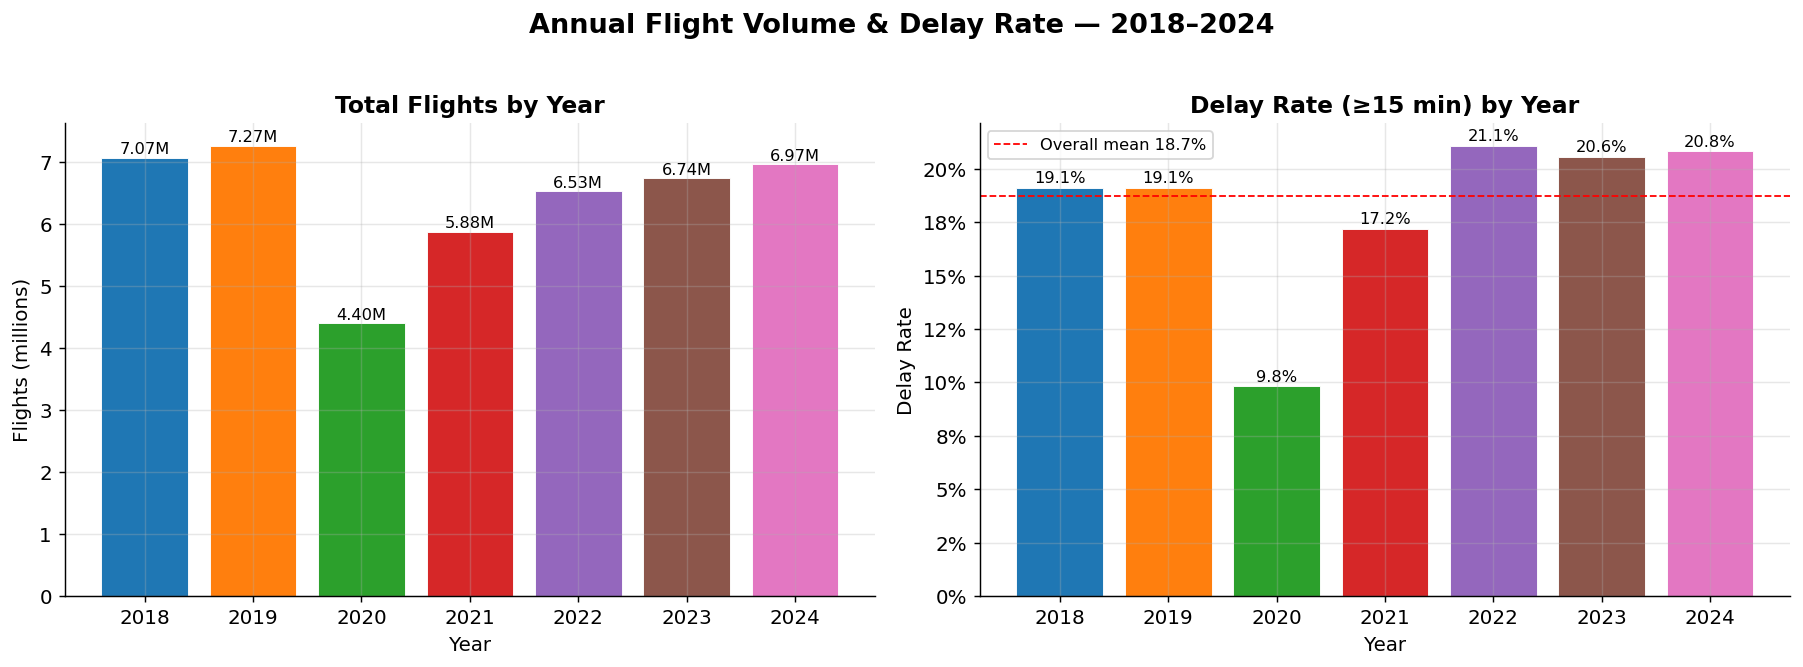

In [ ]:
yearly = (
    df.groupby('Year')
      .agg(flights=('ArrDel15','count'), delay_rate=('ArrDel15','mean'))
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flight Volume
ax = axes[0]
bars = ax.bar(yearly['Year'].astype(str), yearly['flights'] / 1e6,
              color=[PALETTE[y] for y in yearly['Year']], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, yearly['flights']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
ax.set_title('Total Flights by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Flights (millions)')
ax.set_xlabel('Year')

# Delay Rate
ax = axes[1]
bars = ax.bar(yearly['Year'].astype(str), yearly['delay_rate'],
              color=[PALETTE[y] for y in yearly['Year']], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, yearly['delay_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.1%}', ha='center', va='bottom', fontsize=9)
pct_fmt(ax, decimals=0)
ax.set_title('Delay Rate (≥15 min) by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Delay Rate')
ax.set_xlabel('Year')
ax.axhline(df['ArrDel15'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'Overall mean {df["ArrDel15"].mean():.1%}')
ax.legend(fontsize=9)

fig.suptitle('Annual Flight Volume & Delay Rate — 2018–2024',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_annual_overview.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Note: 2020 volume collapse (−39%) reflects COVID-19 shutdown.')
print('   Post-2020 delay rates are uniformly higher (~21%) than pre-COVID (~19%).')

   Note: 2020 volume collapse (−37%) reflects COVID-19 shutdown.
   Post-2020 delay rates are uniformly higher (~21%) than pre-COVID (~19%).


---
## Section 4 — Monthly Seasonality by Year (Jan–Dec)

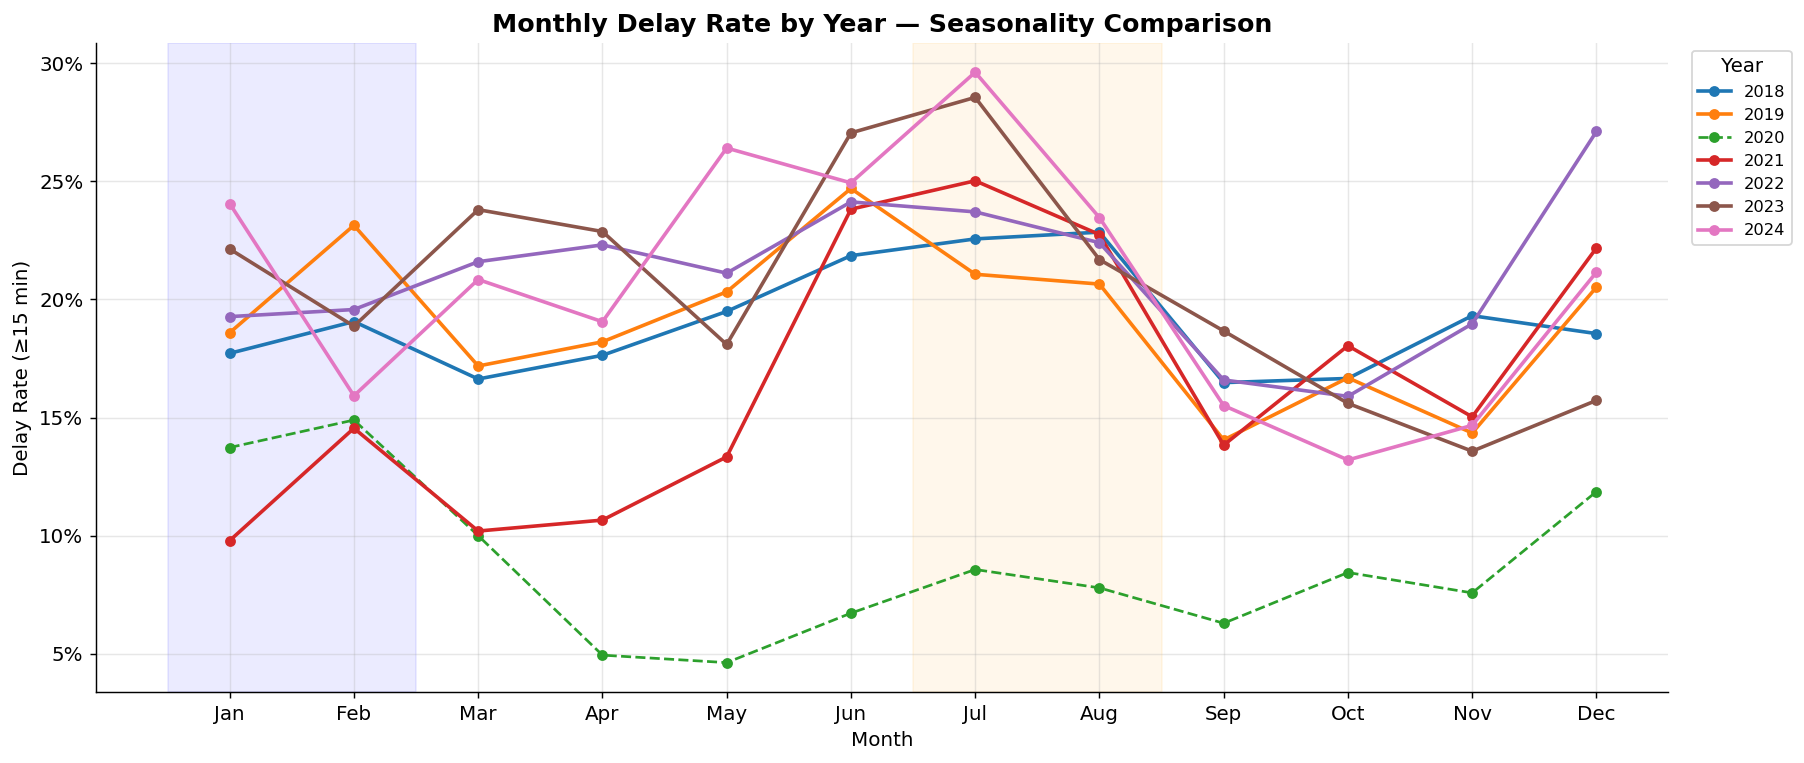

In [ ]:
# 4a. Line chart: delay rate by month, one line per year
monthly = (
    df.groupby(['Year','Month'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for year in YEARS:
    sub = monthly[monthly['Year'] == year].sort_values('Month')
    # dashed for COVID year
    ls  = '--' if year == 2020 else '-'
    lw  = 1.5  if year == 2020 else 2.0
    ax.plot(sub['Month'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=lw, marker='o', markersize=5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
pct_fmt(ax, decimals=0)
ax.set_title('Monthly Delay Rate by Year — Seasonality Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Shade summer and winter peaks
ax.axvspan(6.5, 8.5, alpha=0.08, color='orange', label='Summer Peak')
ax.axvspan(0.5, 2.5, alpha=0.08, color='blue',   label='Winter Peak')

plt.tight_layout()
plt.savefig('fig_02_monthly_delay_by_year.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Two seasonal peaks are consistently present:')
print('   - Winter (Dec–Jan): Likely due to weather-driven delays (ice, snow, low visibility)')
print('   - Summer (Jun–Aug): Likely due to convective storms + demand congestion')
print('   2020 collapses entirely — especially Apr–Jun during lockdown.')

   Two seasonal peaks are consistently present:
   - Winter (Dec–Jan): Likely due to weather-driven delays (ice, snow, low visibility)
   - Summer (Jun–Aug): Likely due to convective storms + demand congestion
   2020 collapses entirely — especially Apr–Jun during lockdown.


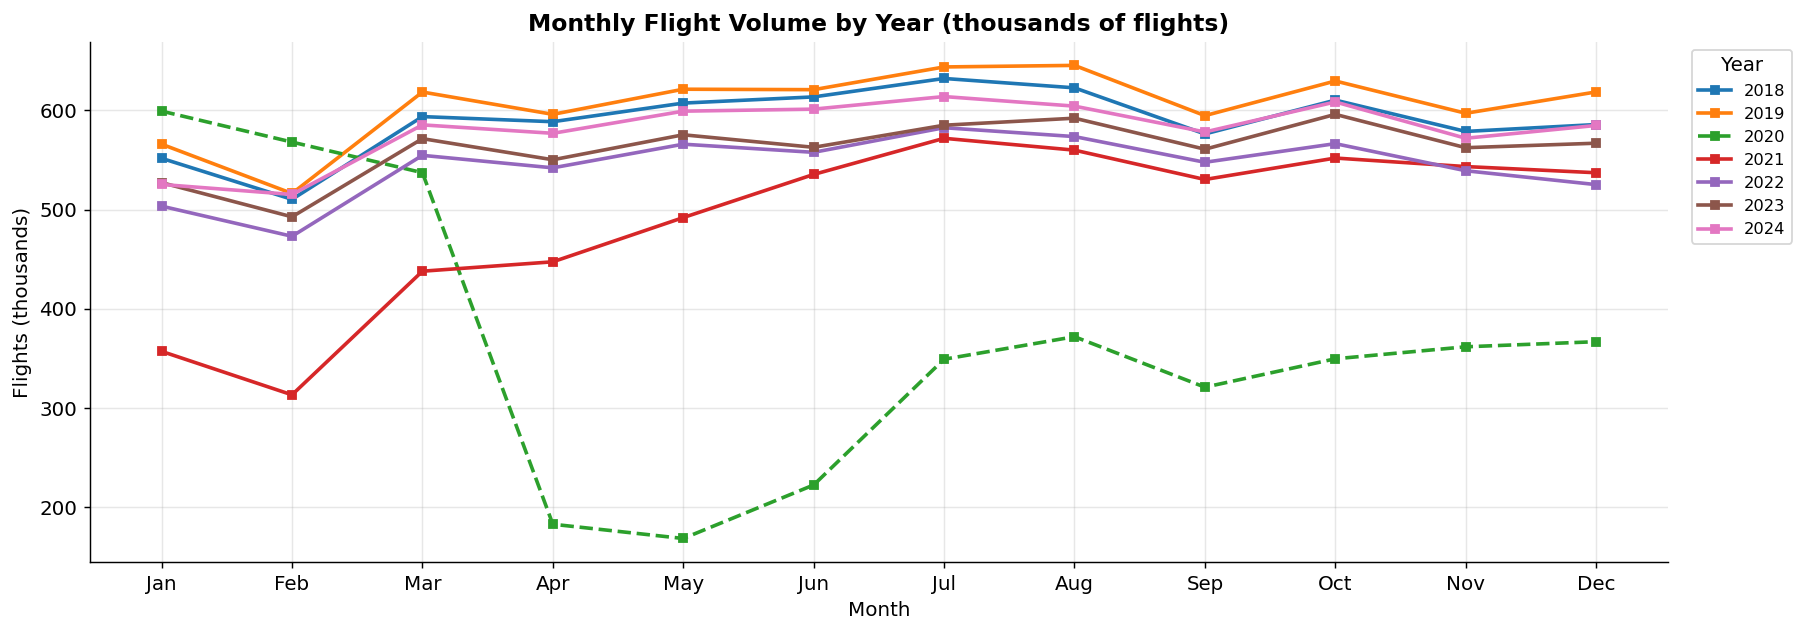

In [ ]:
# 4b. Monthly flight VOLUME by year (area chart)
fig, ax = plt.subplots(figsize=(14, 5))

for year in YEARS:
    sub = monthly[monthly['Year'] == year].sort_values('Month')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['Month'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='s', markersize=4)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
ax.set_title('Monthly Flight Volume by Year (thousands of flights)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_03_monthly_volume_by_year.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Small but consistent increased volume reflects summer travel demand surge (Jun–Aug) in every year.')
print('   Feb dip = shortest month.  2020 Apr–Jun plunge = COVID grounding.')

   Small but consistent increased volume reflects summer travel demand surge (Jun–Aug) in every year.
   Feb dip = shortest month.  2020 Apr–Jun plunge = COVID grounding.


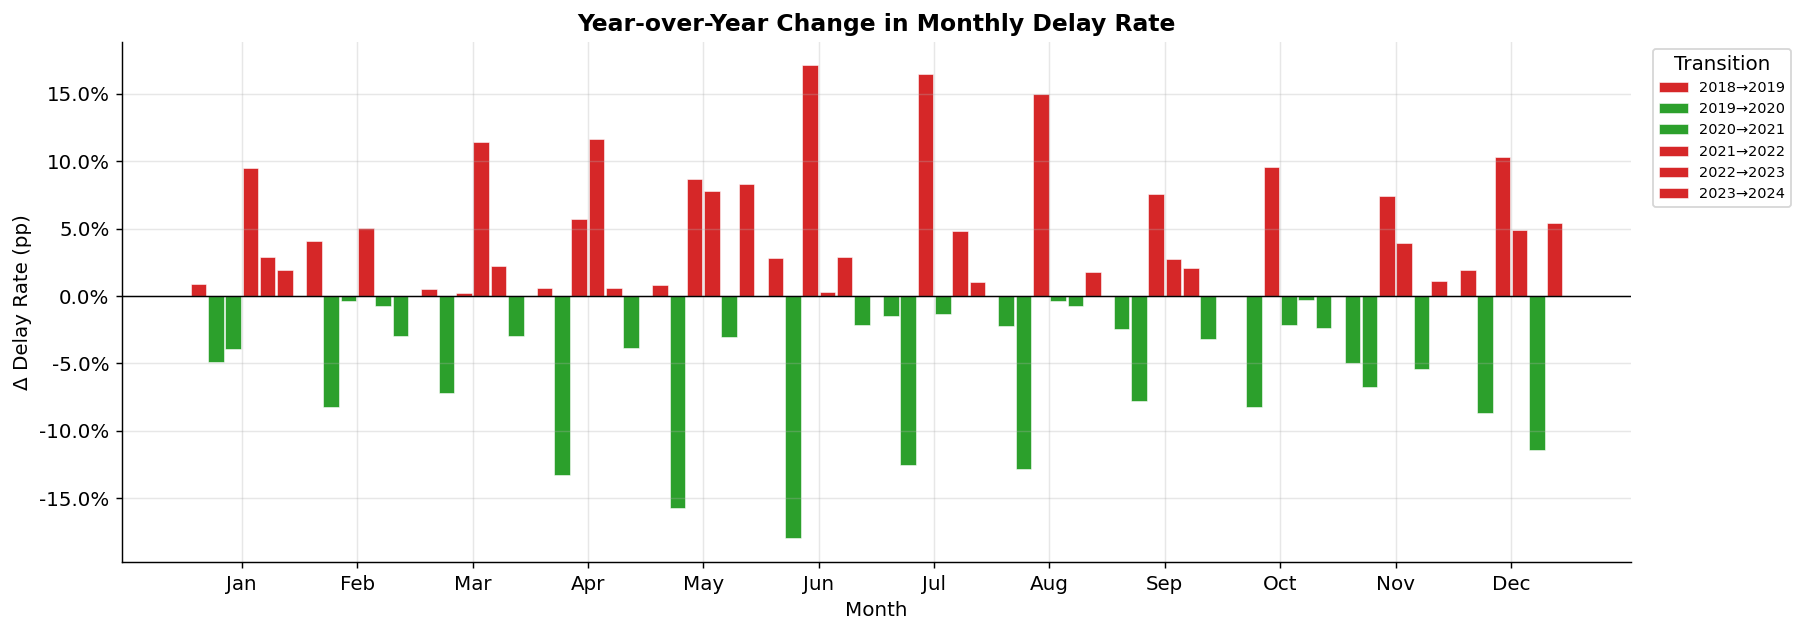

In [ ]:
# 4c. Year-over-Year monthly delay rate DELTA (vs prior year)
monthly_pivot = monthly.pivot(index='Month', columns='Year', values='delay_rate')
yoy_delta     = monthly_pivot.diff(axis=1).drop(columns=YEARS[0])  # drop 2018 (no prior)

fig, ax = plt.subplots(figsize=(14, 5))
cmap_diverge = plt.cm.RdYlGn_r  # red = delay increase, green = decrease

x      = np.arange(12)
n_yrs  = len(YEARS) - 1
width  = 0.9 / n_yrs

for i, year in enumerate(YEARS[1:]):
    vals   = yoy_delta[year].values
    offset = (i - n_yrs / 2 + 0.5) * width
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in vals]
    ax.bar(x + offset, vals, width=width * 0.9,
           color=colors, edgecolor='white', linewidth=0.3,
           label=f'{year - 1}→{year}')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)])
pct_fmt(ax, decimals=1)
ax.set_title('Year-over-Year Change in Monthly Delay Rate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Δ Delay Rate (pp)')
ax.legend(title='Transition', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('fig_04_monthly_yoy_delta.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Red = delay rate worsened vs prior year.  Green = improved.')
print('   2019→2020 shows dramatic green (COVID reduced demand AND delays).')
print('   2020→2021 also remains green as industry pushes initial recovery but returns to red post 2021.')

   Red = delay rate worsened vs prior year.  Green = improved.
   2019→2020 shows dramatic green (COVID reduced demand AND delays).
   2020→2021 also remains green as industry pushes initial recovery but returns to red post 2021.


---
## Section 5 — Day-of-Week Seasonality by Year (Mon–Sun)

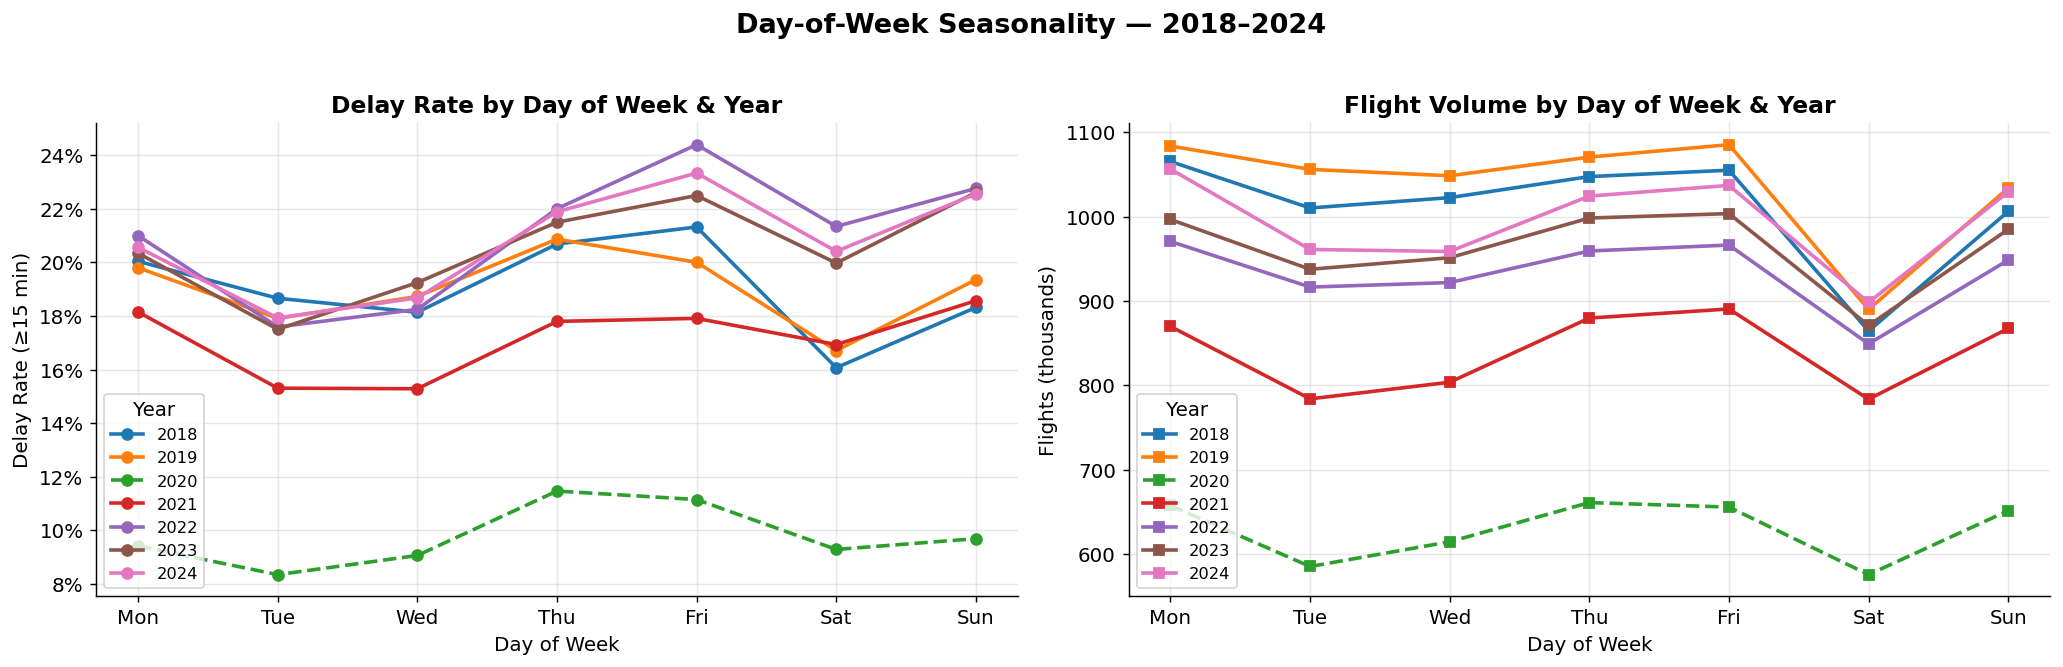

In [ ]:
# 5a. Line chart: delay rate by day of week, one line per year
dow = (
    df.groupby(['Year','DayOfWeek'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Delay rate
ax = axes[0]
for year in YEARS:
    sub = dow[dow['Year'] == year].sort_values('DayOfWeek')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['DayOfWeek'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='o', markersize=6)

ax.set_xticks(range(1, 8))
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
pct_fmt(ax)
ax.set_title('Delay Rate by Day of Week & Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', fontsize=9)

# Flight volume
ax = axes[1]
for year in YEARS:
    sub = dow[dow['Year'] == year].sort_values('DayOfWeek')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['DayOfWeek'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='s', markersize=5)

ax.set_xticks(range(1, 8))
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
ax.set_title('Flight Volume by Day of Week & Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', fontsize=9)

fig.suptitle('Day-of-Week Seasonality — 2018–2024',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_05_dow_seasonality.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Friday typically shows the highest delay rate (Likely due to network congestion).')
print('   Tuesdays and Wednesdays typically shows the lowest delay rate.')
print('   This day-of-week pattern is structurally stable across most years, including 2020.')

   Friday typically shows the highest delay rate (Likely due to network congestion).
   Tuesdays and Wednesdays typically shows the lowest delay rate.
   This day-of-week pattern is structurally stable across most years, including 2020.


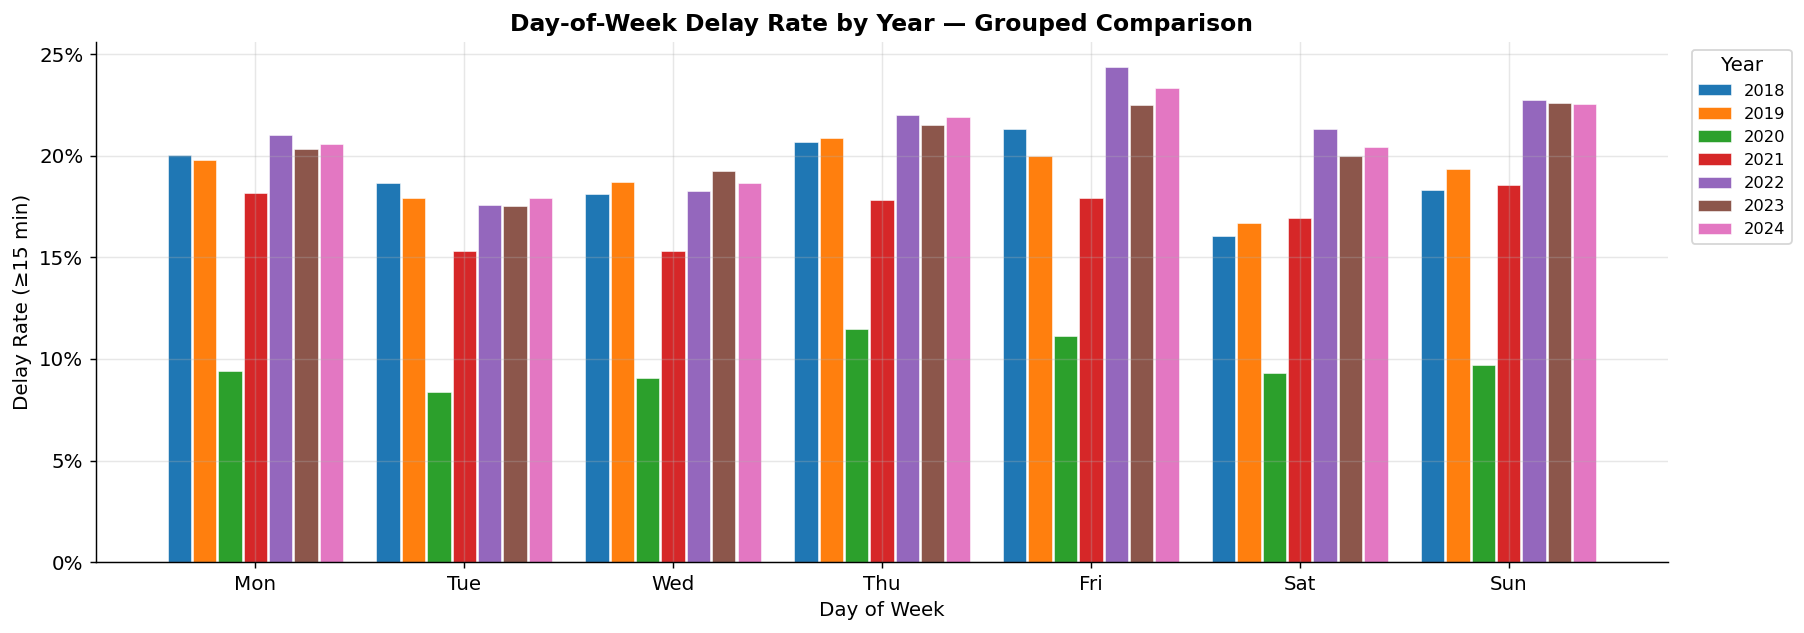

In [ ]:
# 5b. Grouped bar chart — delay rate by DoW for each year
dow_pivot = dow.pivot(index='DayOfWeek', columns='Year', values='delay_rate')

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(7)
n     = len(YEARS)
w     = 0.85 / n

for i, year in enumerate(YEARS):
    vals   = dow_pivot[year].values
    offset = (i - n/2 + 0.5) * w
    ax.bar(x + offset, vals, width=w * 0.92,
           color=PALETTE[year], label=str(year), edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([DOW_NAMES[d] for d in range(1, 8)])
pct_fmt(ax)
ax.set_title('Day-of-Week Delay Rate by Year — Grouped Comparison',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_06_dow_grouped_bar.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Hourly / Intraday Seasonality by Year

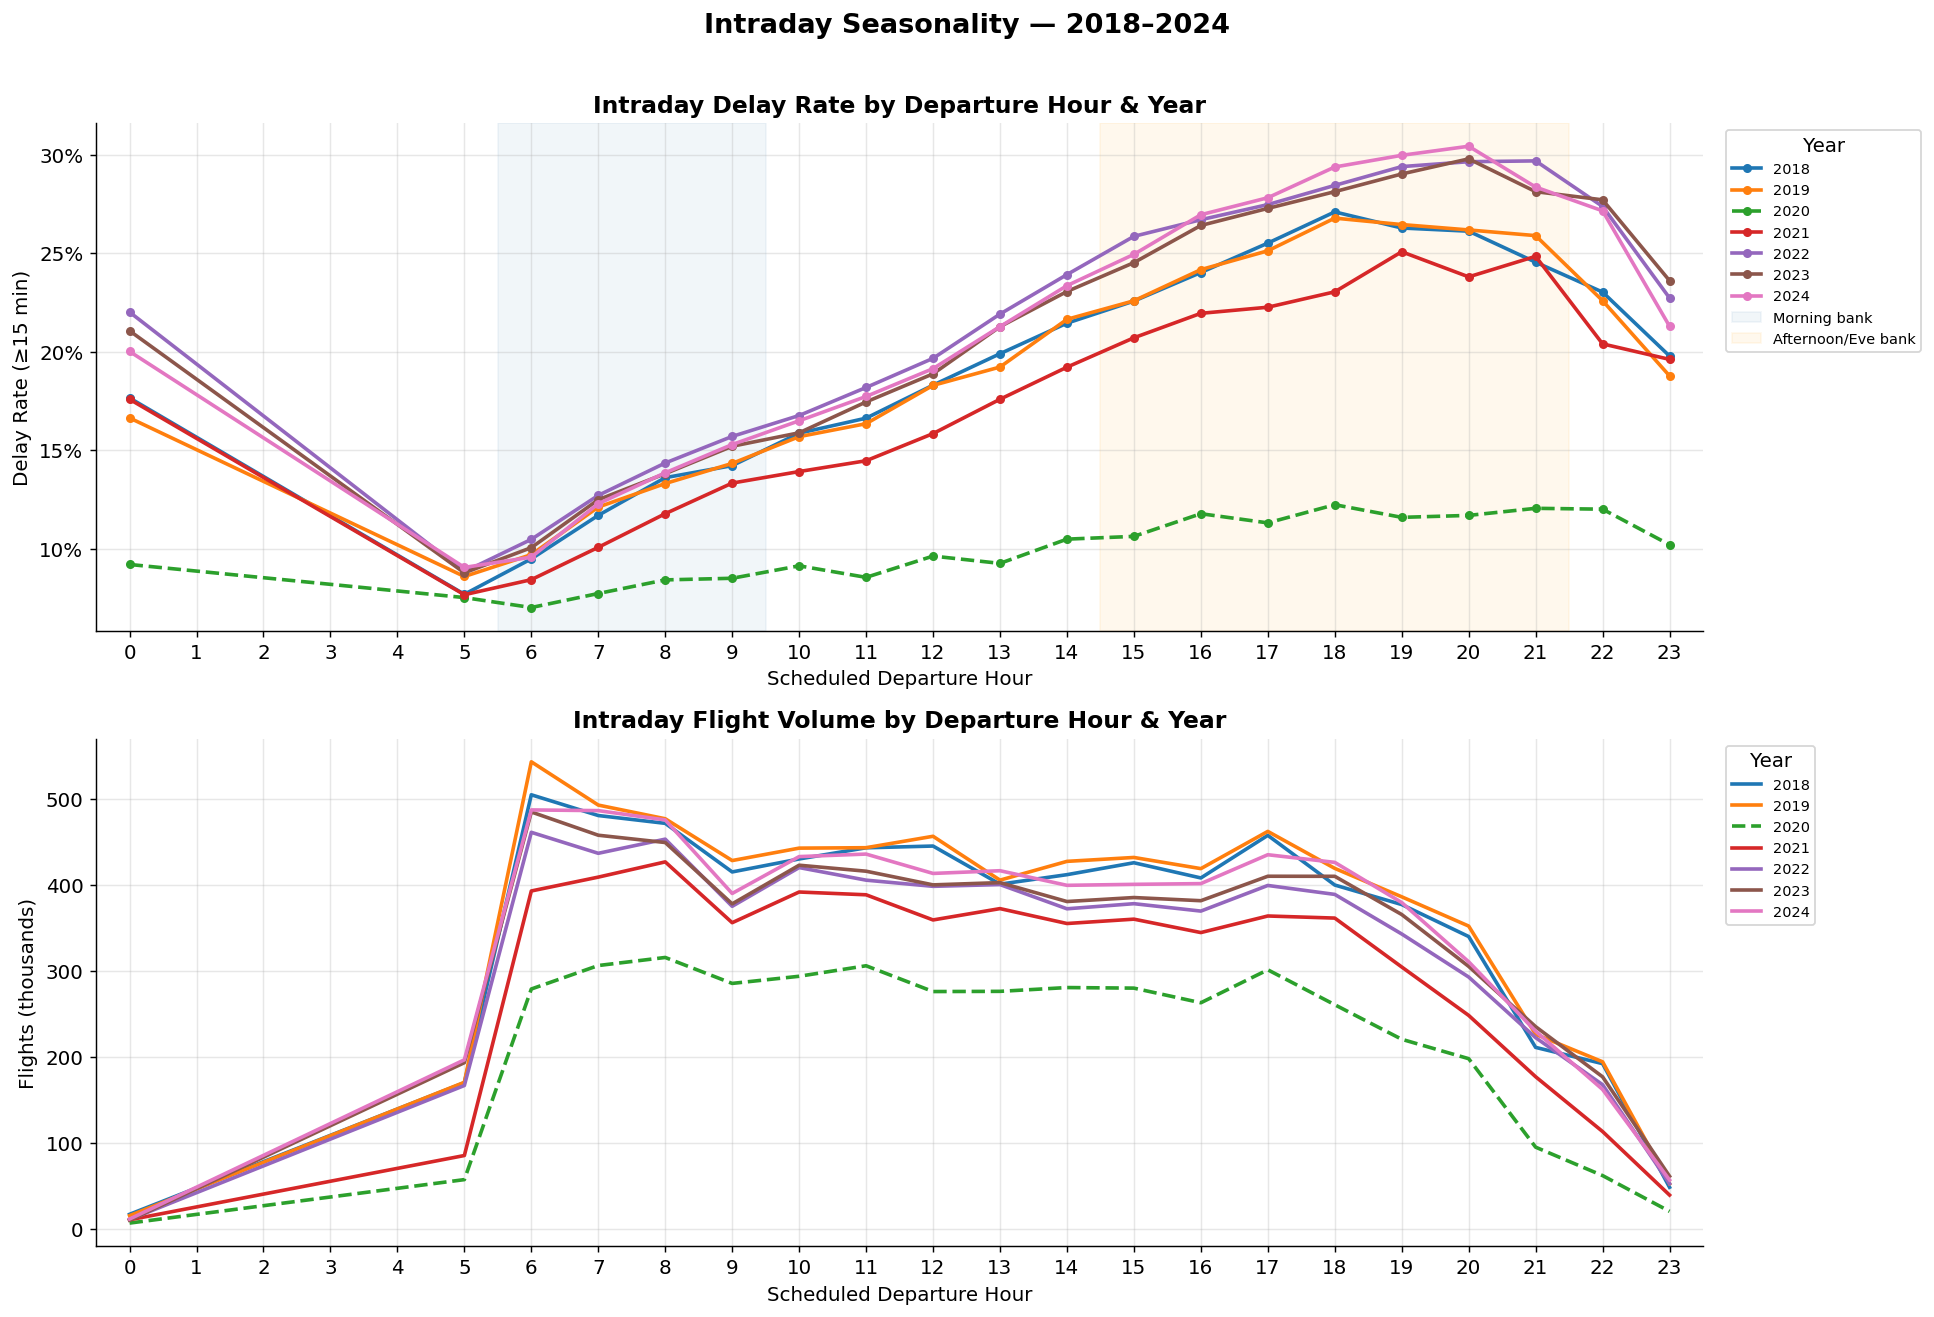

In [ ]:
# 6a. Delay rate by departure hour, per year
hourly = (
    df.groupby(['Year','dep_hour'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)
# Only hours with meaningful volume (filter out midnight wrap-arounds with < 0.1% of flights)
total_by_yr = hourly.groupby('Year')['flights'].transform('sum')
hourly      = hourly[hourly['flights'] / total_by_yr > 0.001].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Delay rate by hour
ax = axes[0]
for year in YEARS:
    sub = hourly[hourly['Year'] == year].sort_values('dep_hour')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['dep_hour'], sub['delay_rate'],
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2, marker='o', markersize=4)

# Shade morning and evening banks
ax.axvspan(5.5, 9.5,  alpha=0.07, color='steelblue', label='Morning bank')
ax.axvspan(14.5, 21.5, alpha=0.07, color='orange',   label='Afternoon/Eve bank')
pct_fmt(ax)
ax.set_xticks(range(0, 24))
ax.set_title('Intraday Delay Rate by Departure Hour & Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(-0.5, 23.5)

# Volume by hour
ax = axes[1]
for year in YEARS:
    sub = hourly[hourly['Year'] == year].sort_values('dep_hour')
    ls  = '--' if year == 2020 else '-'
    ax.plot(sub['dep_hour'], sub['flights'] / 1000,
            label=str(year), color=PALETTE[year],
            linestyle=ls, linewidth=2)

ax.set_xticks(range(0, 24))
ax.set_title('Intraday Flight Volume by Departure Hour & Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Flights (thousands)')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(-0.5, 23.5)

fig.suptitle('Intraday Seasonality — 2018–2024',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_07_intraday_seasonality.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Early morning departures (05:00–08:00) have a massive increase in volume')
print('   Delays increase almost linearly from 05:00 throughout the day, peaking at 18:00–20:00 (Likely network congestion propagation).')
print('   IMPORTANT for the T-2h window: the departure hour itself seems to be a strong predictor.')

   Early morning departures (05:00–08:00) have a massive increase in volume
   Delays increase almost linearly from 05:00 throughout the day, peaking at 18:00–20:00 (Likely network congestion propagation).
   IMPORTANT for the T-2h window: the departure hour itself seems to be a strong predictor.


---
## Section 7 — Quarterly Seasonality by Year

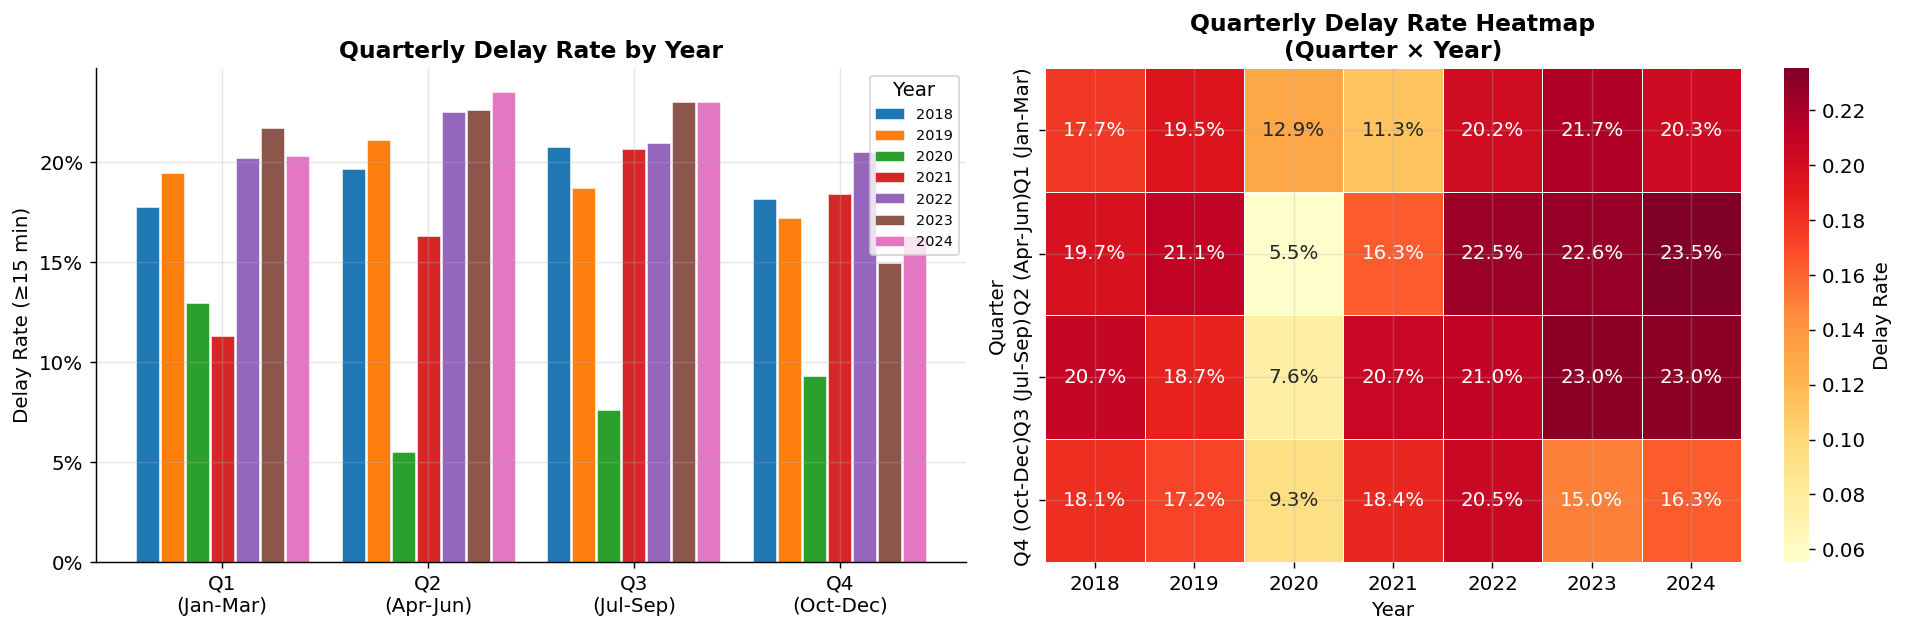

In [ ]:
quarterly = (
    df.groupby(['Year','Quarter'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar: delay rate
ax = axes[0]
x = np.arange(4)
n = len(YEARS)
w = 0.85 / n
for i, year in enumerate(YEARS):
    sub    = quarterly[quarterly['Year'] == year].sort_values('Quarter')
    offset = (i - n/2 + 0.5) * w
    ax.bar(x + offset, sub['delay_rate'], width=w * 0.92,
           color=PALETTE[year], label=str(year), edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([QTR_NAMES[q] for q in range(1, 5)])
pct_fmt(ax)
ax.set_title('Quarterly Delay Rate by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Year', fontsize=8)

# Heatmap: quarter × year
ax = axes[1]
qtr_pivot = quarterly.pivot(index='Quarter', columns='Year', values='delay_rate')
qtr_pivot.index = [QTR_NAMES[q].replace('\n',' ') for q in qtr_pivot.index]
sns.heatmap(qtr_pivot, annot=True, fmt='.1%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Delay Rate'})
ax.set_title('Quarterly Delay Rate Heatmap\n(Quarter × Year)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Quarter')

plt.tight_layout()
plt.savefig('fig_08_quarterly_seasonality.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Q2-3 (Covering early and late summer respectively) are typically the highest-delay quarters, with 2020 being an expected exception.')
print('   Q4 is typically the lowest outside of COVID.')
print('   2020 Q1 already shows COVID impact (March shutdown); Q2 is anomalously low.')

   Q2-3 (Covering early and late summer respectively) are typically the highest-delay quarters, with 2020 being an expected exception.
   Q4 is typically the lowest outside of COVID.
   2020 Q1 already shows COVID impact (March shutdown); Q2 is anomalously low.


---
## Section 8 — Heatmap Grid: Month × Year and DoW × Year

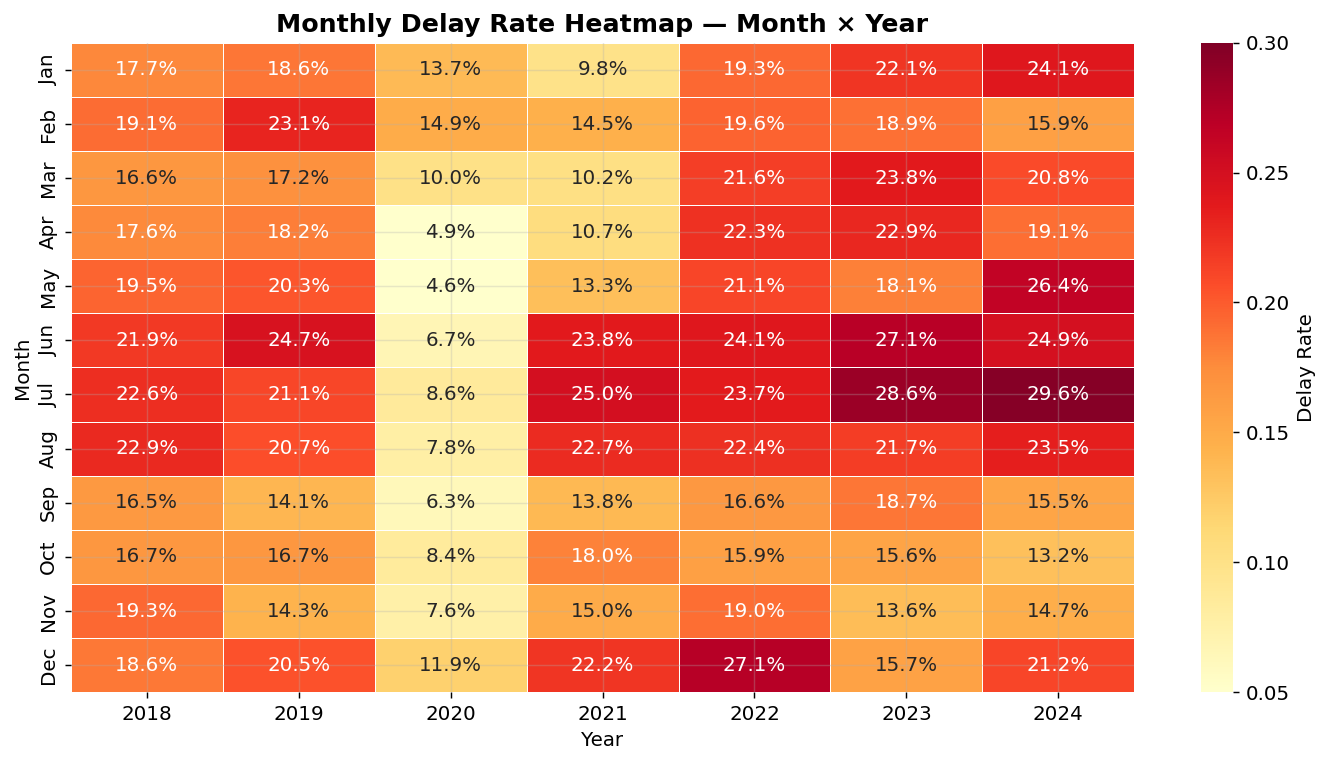

In [ ]:
# 8a. Delay Rate Heatmap — Month × Year
month_pivot = (
    df.groupby(['Year','Month'])['ArrDel15']
      .mean()
      .unstack('Year')
)
month_pivot.index = [MONTH_NAMES[m] for m in month_pivot.index]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    month_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.30,
)
ax.set_title('Monthly Delay Rate Heatmap — Month × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

plt.tight_layout()
plt.savefig('fig_09a_heatmap_month_year.png', bbox_inches='tight')
plt.show()

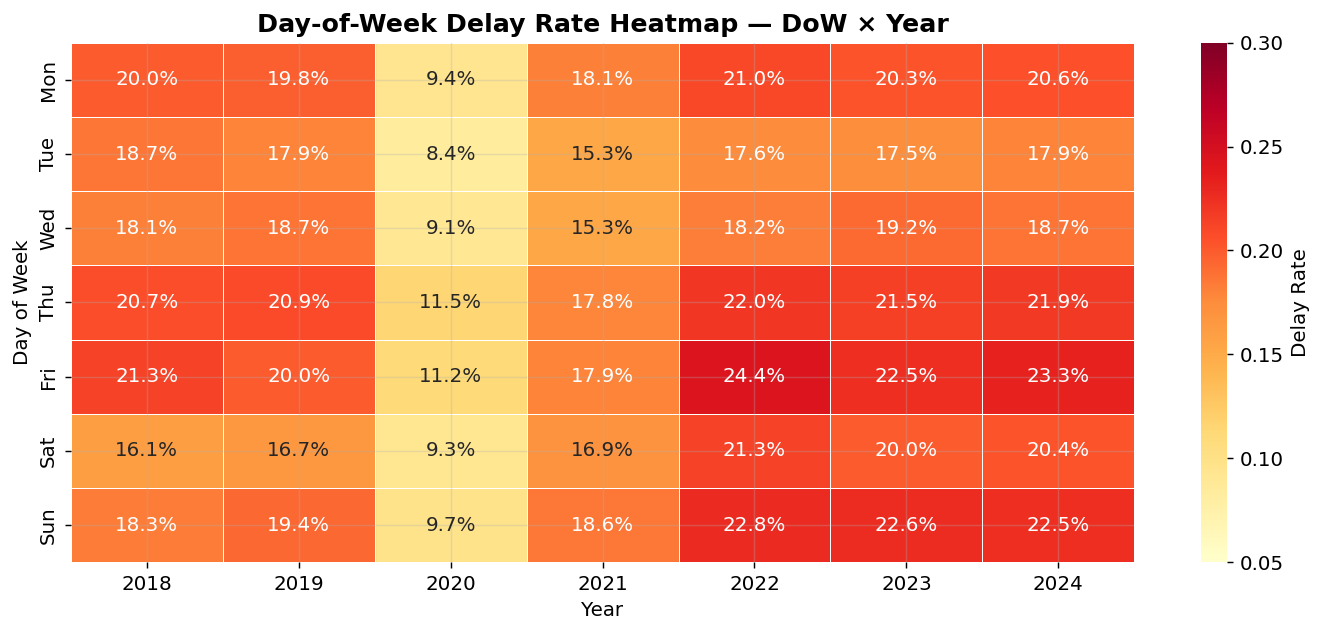

In [ ]:
# 8b. Delay Rate Heatmap — Day-of-Week × Year
dow_pivot = (
    df.groupby(['Year','DayOfWeek'])['ArrDel15']
      .mean()
      .unstack('Year')
)
dow_pivot.index = [DOW_NAMES[d] for d in dow_pivot.index]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    dow_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.30,
)
ax.set_title('Day-of-Week Delay Rate Heatmap — DoW × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('fig_09b_heatmap_dow_year.png', bbox_inches='tight')
plt.show()

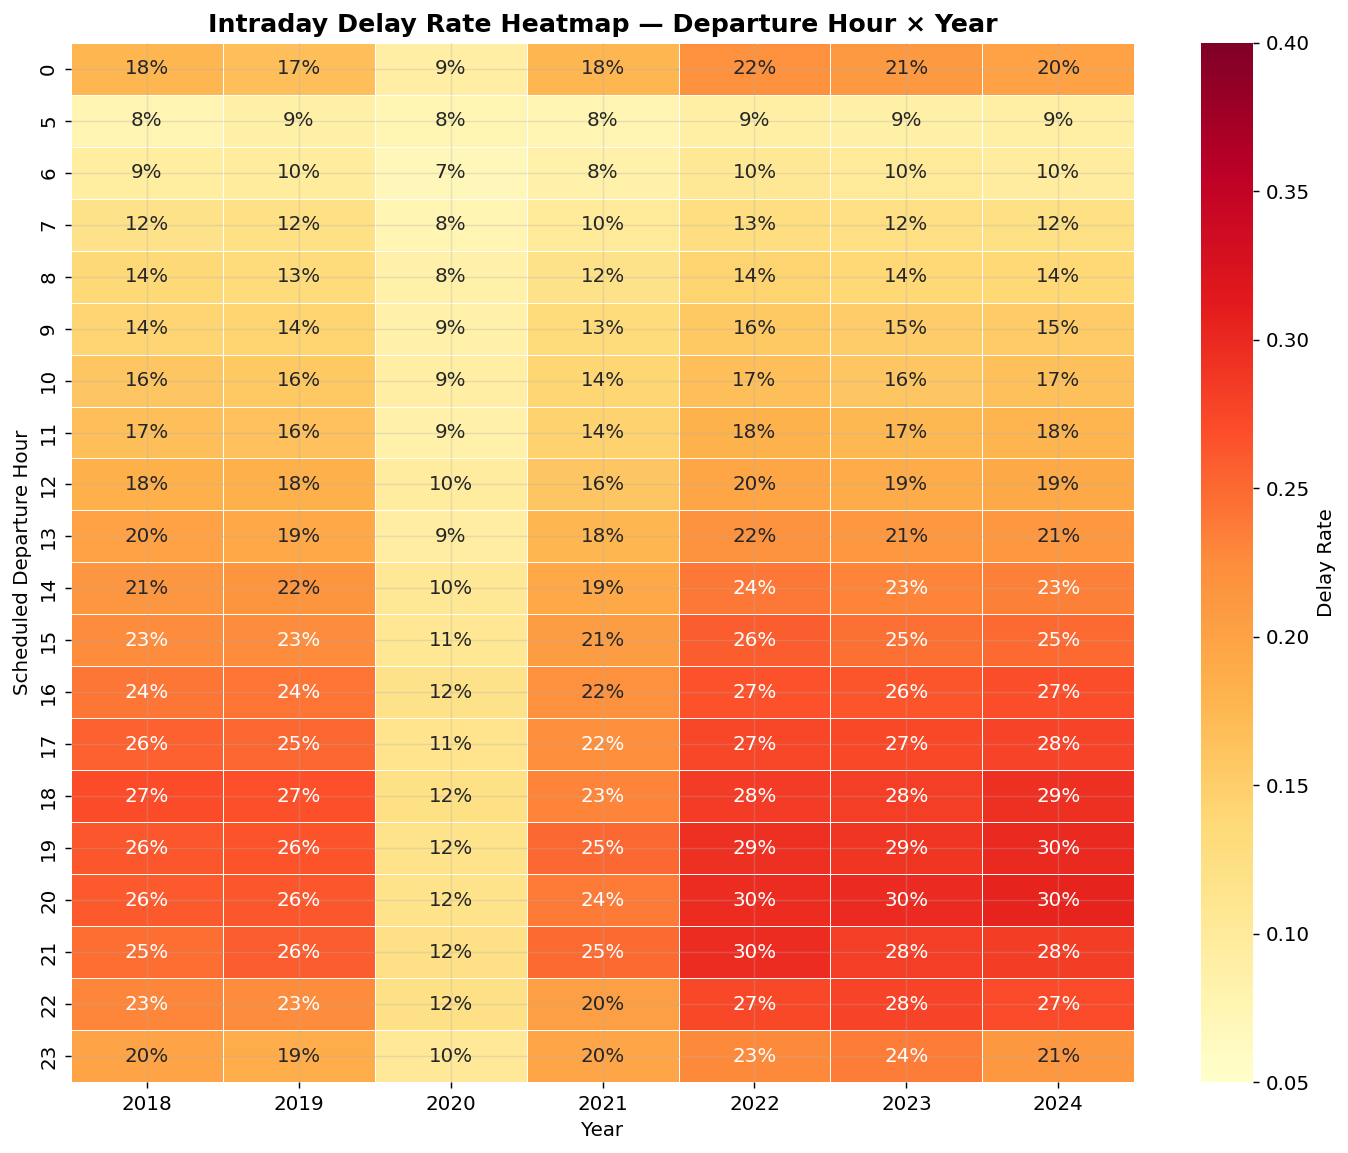

In [ ]:
# 8c. Delay Rate Heatmap — Departure Hour × Year
hr_pivot = (
    df.groupby(['Year','dep_hour'])['ArrDel15']
      .agg(delay_rate='mean', cnt='count')
      .reset_index()
)
# Filter low-volume hour-year combos
yr_totals = hr_pivot.groupby('Year')['cnt'].transform('sum')
hr_pivot  = hr_pivot[hr_pivot['cnt'] / yr_totals > 0.001]
hr_pivot2 = hr_pivot.pivot(index='dep_hour', columns='Year', values='delay_rate')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    hr_pivot2,
    annot    = True,
    fmt      = '.0%',
    cmap     = 'YlOrRd',
    linewidths = 0.3,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.05,
    vmax     = 0.40,
)
ax.set_title('Intraday Delay Rate Heatmap — Departure Hour × Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Scheduled Departure Hour')

plt.tight_layout()
plt.savefig('fig_09c_heatmap_hour_year.png', bbox_inches='tight')
plt.show()


In [ ]:
print('   The hour × year heatmap appears to be of strong importance for our models:')
print('   High delay hours (18–21) are consistent across ALL years, even 2020.')

   The hour × year heatmap appears to be of strong importance for our models:
   High delay hours (18–21) are consistent across ALL years, even 2020.


---
## Section 9 — COVID Structural Break: Annotated Monthly Time Series

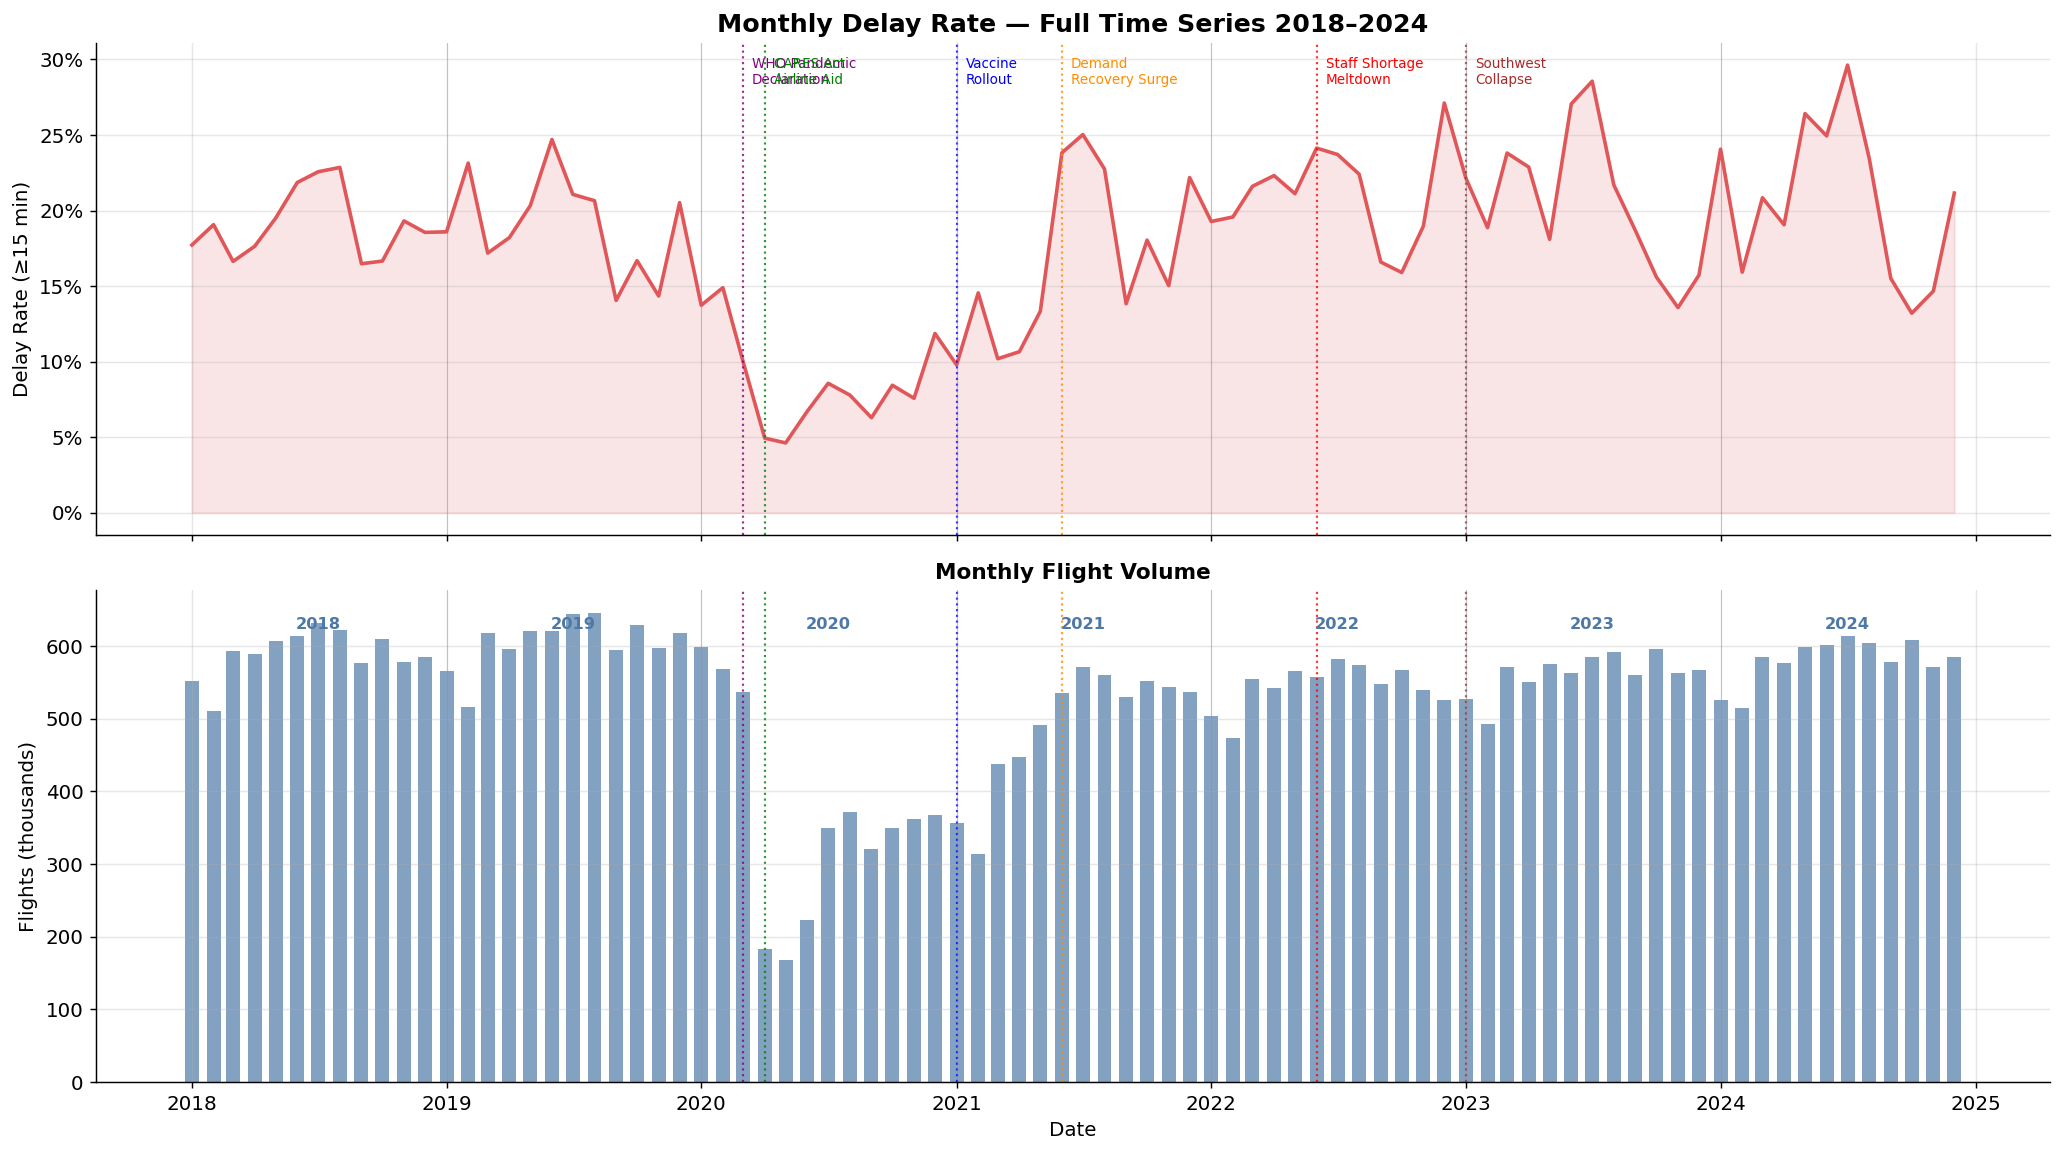

In [ ]:
# Full monthly time series 2018–2024
monthly_ts = (
    df.groupby(['Year','Month'])
      .agg(delay_rate=('ArrDel15','mean'), flights=('ArrDel15','count'))
      .reset_index()
)
monthly_ts['period'] = pd.to_datetime(
    monthly_ts['Year'].astype(str) + '-' +
    monthly_ts['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_ts = monthly_ts.sort_values('period')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# — Panel 1: Delay rate —
ax1.plot(monthly_ts['period'], monthly_ts['delay_rate'],
         color='#e15759', linewidth=2, label='Monthly delay rate')
ax1.fill_between(monthly_ts['period'], monthly_ts['delay_rate'],
                 alpha=0.15, color='#e15759')
pct_fmt(ax1)
ax1.set_ylabel('Delay Rate (≥15 min)', fontsize=11)
ax1.set_title('Monthly Delay Rate — Full Time Series 2018–2024',
              fontsize=14, fontweight='bold')

# Panel 2: Flight volume
ax2.bar(monthly_ts['period'], monthly_ts['flights'] / 1000,
        width=20, color='#4e79a7', alpha=0.7, label='Flights (thousands)')
ax2.set_ylabel('Flights (thousands)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title('Monthly Flight Volume', fontsize=12, fontweight='bold')

# Annotations
events = [
    ('2020-03-01', 'WHO Pandemic\nDeclaration', 'purple'),
    ('2020-04-01', 'CARES Act\nAirline Aid',    'green'),
    ('2021-01-01', 'Vaccine\nRollout',           'blue'),
    ('2021-06-01', 'Demand\nRecovery Surge',     'darkorange'),
    ('2022-06-01', 'Staff Shortage\nMeltdown',   'red'),
    ('2023-01-01', 'Southwest\nCollapse',        'brown'),
]

for date_str, label, color in events:
    dt = pd.Timestamp(date_str)
    for ax in [ax1, ax2]:
        ax.axvline(dt, color=color, linestyle=':', linewidth=1.2, alpha=0.8)
    ax1.annotate(
        label, xy=(dt, ax1.get_ylim()[1] * 0.97),
        xytext=(5, 0), textcoords='offset points',
        fontsize=7.5, color=color, va='top',
        rotation=0,
    )

# Year boundaries
for yr in range(2019, 2025):
    for ax in [ax1, ax2]:
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                   linestyle='-', linewidth=0.5, alpha=0.4)

# Year labels
for yr in YEARS:
    ax2.text(pd.Timestamp(f'{yr}-07-01'), ax2.get_ylim()[1] * 0.92,
             str(yr), ha='center', fontsize=9, color='#4e79a7', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_10_covid_annotated_ts.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Structural breaks identified:')
print('   - 2020 Q2: Demand collapse — low volume, low delays ("easy" classification period)')
print('   - 2021 H2: Demand surge + staffing gap → delay spike')
print('   - Jun 2022: Summer meltdown — we see delays actually dip shortly after this event')
print('   - Dec 2022: Southwest Airlines Christmas collapse - consistently volatile spikes in delay rates around this time')
print('   Note: These events and potentially more should be considered in temporal train/test splits.')

   Structural breaks identified:
   - 2020 Q2: Demand collapse — low volume, low delays ("easy" classification period)
   - 2021 H2: Demand surge + staffing gap → delay spike
   - Jun 2022: Summer meltdown — we see delays actually dip shortly after this event
   - Dec 2022: Southwest Airlines Christmas collapse - consistently volatile spikes in delay rates around this time
   Note: These events and potentially more should be considered in temporal train/test splits.


---
## Section 10 — Airline-Level Delay Trends Over Time

C:\Users\han_k\AppData\Local\Temp\ipykernel_20216\1662537290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_yr_cnt = df.groupby('Reporting_Airline')['Year'].nunique()
C:\Users\han_k\AppData\Local\Temp\ipykernel_20216\1662537290.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Reporting_Airline','Year'])['ArrDel15']


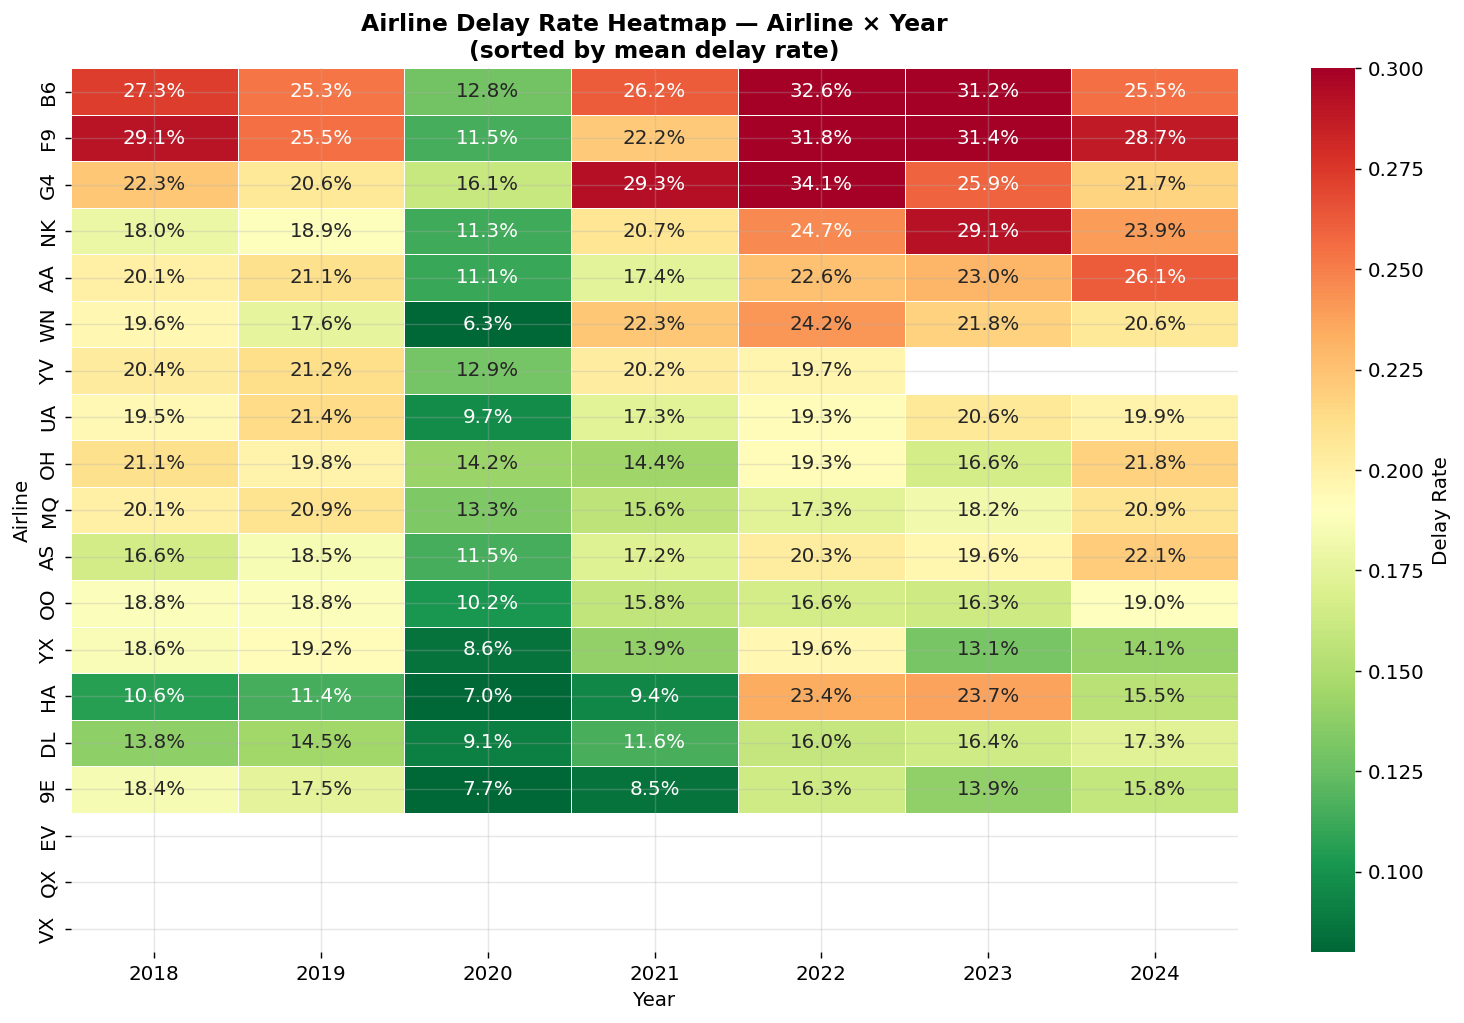

In [ ]:
# Select airlines with consistent presence (>= 5 years of data)
airline_yr_cnt = df.groupby('Reporting_Airline')['Year'].nunique()
top_airlines   = airline_yr_cnt[airline_yr_cnt >= 5].index.tolist()

airline_yr = (
    df[df['Reporting_Airline'].isin(top_airlines)]
      .groupby(['Reporting_Airline','Year'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

# 10a. Heatmap: airline × year
al_pivot = airline_yr.pivot(index='Reporting_Airline',
                             columns='Year',
                             values='delay_rate')
# Sort by mean delay rate (worst to best)
al_pivot = al_pivot.loc[al_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, max(6, len(top_airlines)*0.5)))
sns.heatmap(
    al_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'RdYlGn_r',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.08,
    vmax     = 0.30,
)
ax.set_title('Airline Delay Rate Heatmap — Airline × Year\n(sorted by mean delay rate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Airline')

plt.tight_layout()
plt.savefig('fig_11a_airline_heatmap.png', bbox_inches='tight')
plt.show()

C:\Users\han_k\AppData\Local\Temp\ipykernel_20216\963936920.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Reporting_Airline')['ArrDel15']


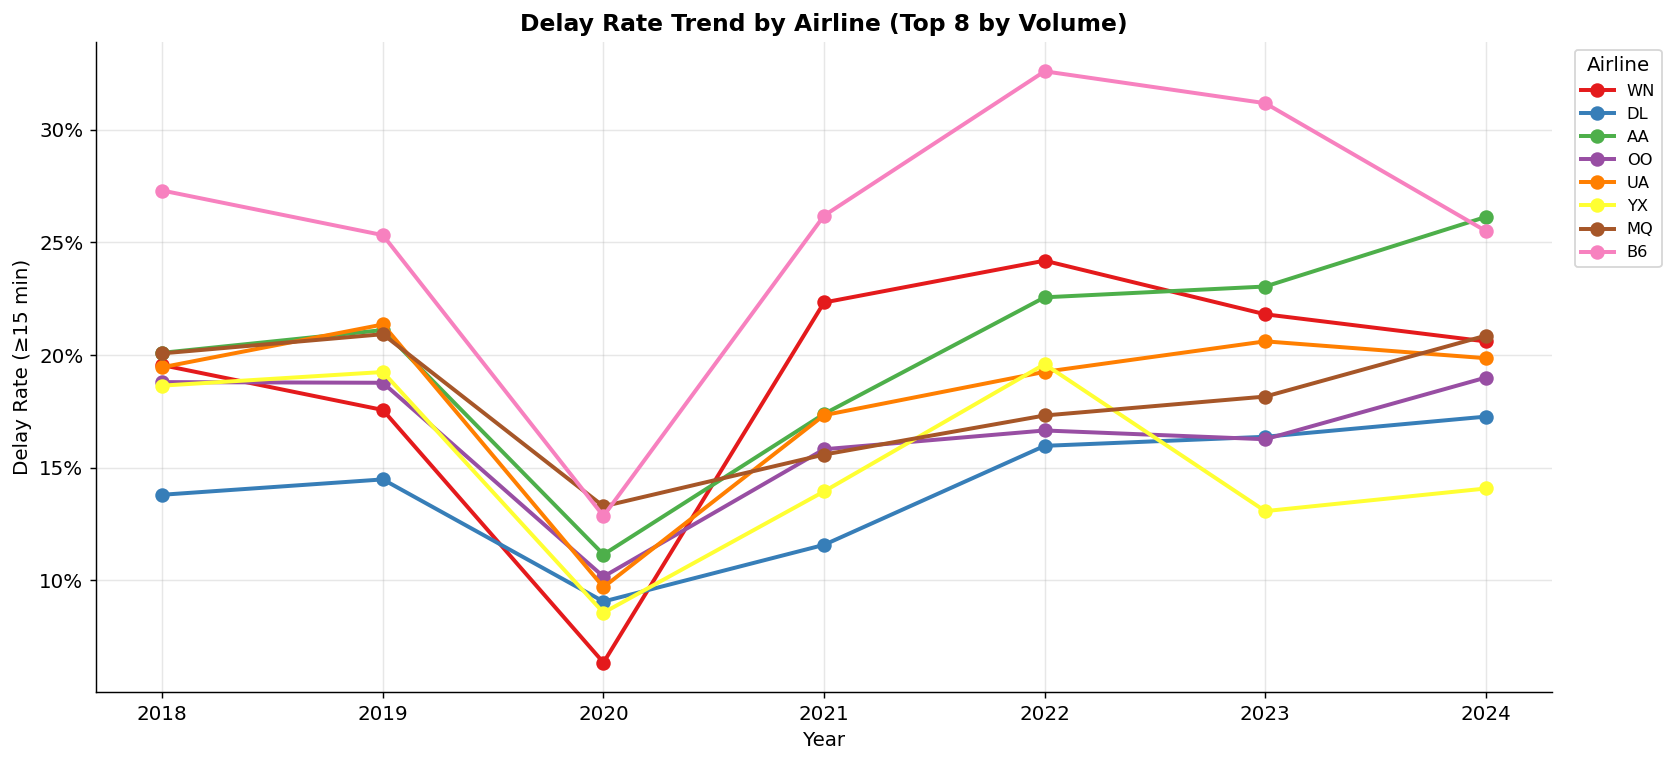

In [ ]:
# 10b. Line chart: airline delay rate trends over years
# Select top 8 airlines by flight volume for readability
top8 = (
    df[df['Reporting_Airline'].isin(top_airlines)]
      .groupby('Reporting_Airline')['ArrDel15']
      .count()
      .nlargest(8)
      .index.tolist()
)

al_palette = dict(zip(top8, sns.color_palette('Set1', len(top8))))

fig, ax = plt.subplots(figsize=(13, 6))
for al in top8:
    sub = airline_yr[airline_yr['Reporting_Airline'] == al].sort_values('Year')
    ax.plot(sub['Year'], sub['delay_rate'],
            label=al, color=al_palette[al],
            linewidth=2.2, marker='o', markersize=7)

pct_fmt(ax)
ax.set_xticks(YEARS)
ax.set_title('Delay Rate Trend by Airline (Top 8 by Volume)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Airline', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_11b_airline_trends.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Airline is a strong categorical feature.')
print('   Some carriers show persistent above-average delays; others improved or saw collapse in delay prevention post-COVID.')
print('   We could consider airline-level rolling delay rate as an engineered feature for the model.')

   Airline is a strong categorical feature.
   Some carriers show persistent above-average delays; others improved or saw collapse in delay prevention post-COVID.
   We could consider airline-level rolling delay rate as an engineered feature for the model.


---
## Section 11 — Distance Group Temporal Patterns

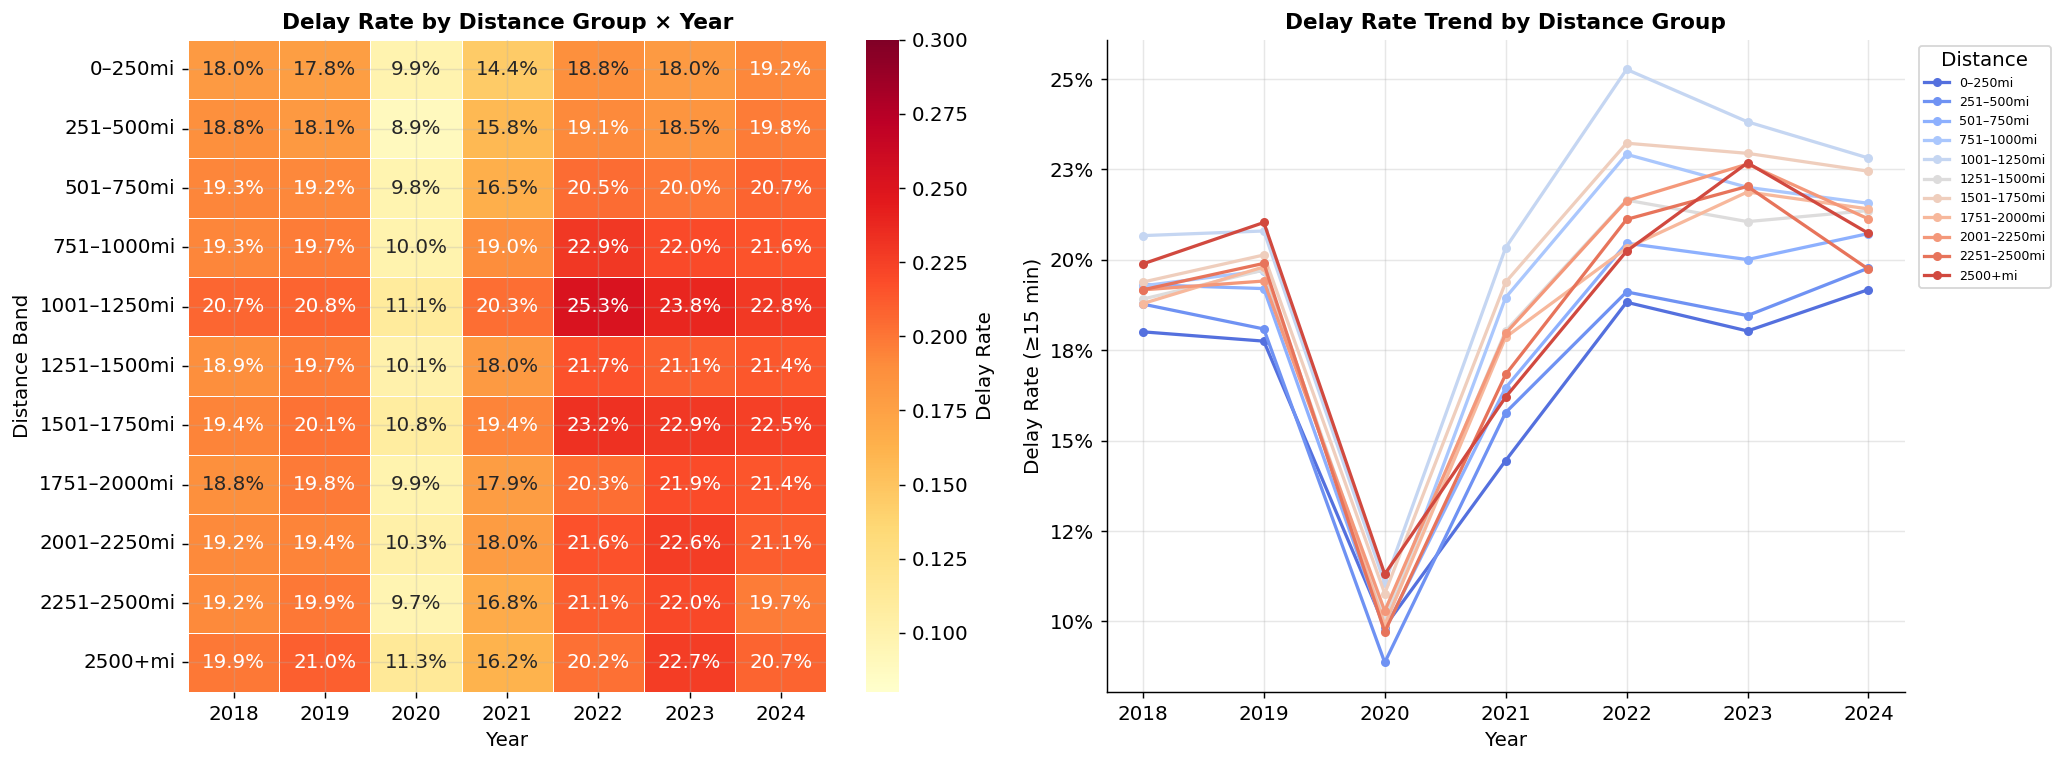

In [ ]:
# Distance group labels (BTS definition: ~250mi bands)
dist_labels = {
    1:'0–250mi', 2:'251–500mi', 3:'501–750mi', 4:'751–1000mi',
    5:'1001–1250mi', 6:'1251–1500mi', 7:'1501–1750mi',
    8:'1751–2000mi', 9:'2001–2250mi', 10:'2251–2500mi', 11:'2500+mi'
}

dg = (
    df.groupby(['Year','DistanceGroup'])['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: distance group × year
ax = axes[0]
dg_pivot = dg.pivot(index='DistanceGroup', columns='Year', values='delay_rate')
dg_pivot.index = [dist_labels.get(i, str(i)) for i in dg_pivot.index]
sns.heatmap(
    dg_pivot,
    annot    = True,
    fmt      = '.1%',
    cmap     = 'YlOrRd',
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate'},
    vmin     = 0.08,
    vmax     = 0.30,
)
ax.set_title('Delay Rate by Distance Group × Year',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Distance Band')

# Line: delay rate by distance group per year
ax = axes[1]
dg_palette = sns.color_palette('coolwarm', 11)
for grp in sorted(dg['DistanceGroup'].unique()):
    sub = dg[dg['DistanceGroup'] == grp].sort_values('Year')
    ax.plot(sub['Year'], sub['delay_rate'],
            label=dist_labels.get(grp, str(grp)),
            color=dg_palette[grp - 1], linewidth=1.8, marker='o', markersize=4)

pct_fmt(ax)
ax.set_xticks(YEARS)
ax.set_title('Delay Rate Trend by Distance Group',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(title='Distance', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig('fig_12_distance_group.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Short-haul flights (0–500mi) tend to have lower delay rates')
print('   the worst rates appear in the middle and longer distance bands.')

   Short-haul flights (0–500mi) tend to have lower delay rates
   the worst rates appear in the middle and longer distance bands.


---
## Section 12 — Weather Condition Delay Rates by Year

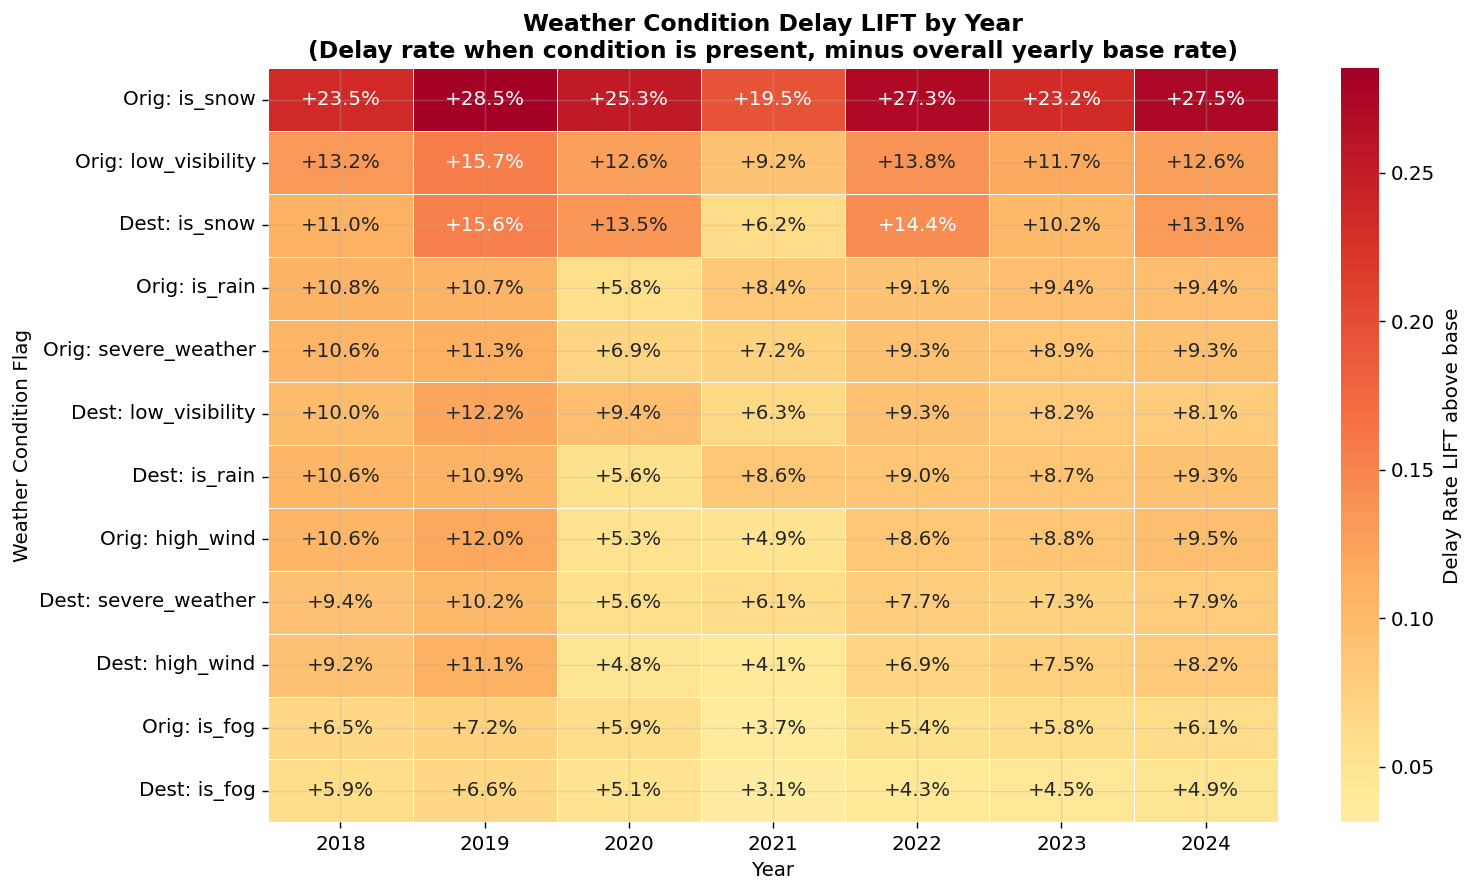

In [ ]:
# Weather condition flag columns
wx_flags = [
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]
wx_flags_present = [c for c in wx_flags if c in df.columns]

records = []
for col in wx_flags_present:
    for year in YEARS:
        sub = df[(df['Year'] == year) & df[col].notna()]
        records.append({
            'flag'      : col.replace('origin_','Orig: ').replace('dest_','Dest: '),
            'year'      : year,
            'delay_rate': sub.loc[sub[col] == 1, 'ArrDel15'].mean(),
            'base_rate' : sub['ArrDel15'].mean(),
        })

wx_df = pd.DataFrame(records)
wx_df['lift'] = wx_df['delay_rate'] - wx_df['base_rate']

# Heatmap: weather flag × year, colored by LIFT (delta above base rate)
lift_pivot = wx_df.pivot(index='flag', columns='year', values='lift')
# Sort by mean lift
lift_pivot = lift_pivot.loc[lift_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    lift_pivot,
    annot    = True,
    fmt      = '+.1%',
    cmap     = 'RdYlGn_r',
    center   = 0,
    linewidths = 0.4,
    ax       = ax,
    cbar_kws = {'label': 'Delay Rate LIFT above base'},
)
ax.set_title(
    'Weather Condition Delay LIFT by Year\n'
    '(Delay rate when condition is present, minus overall yearly base rate)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Weather Condition Flag')

plt.tight_layout()
plt.savefig('fig_13_weather_lift_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   Positive lift = the condition is associated with higher delay probability.')
print('   Snow and low-visibility show the highest and most stable lifts across years.')
print('   Destination weather lift is often weaker but still potentially significant as strong lifts can be seen — both are needed for T-2h features.')

   Positive lift = the condition is associated with higher delay probability.
   Snow and low-visibility show the highest and most stable lifts across years.
   Destination weather lift is often weaker but still potentially significant as strong lifts can be seen — both are needed for T-2h features.


---
## Section 13 — Rolling 4-Week Delay Rate (Full 2018–2024 Trend)

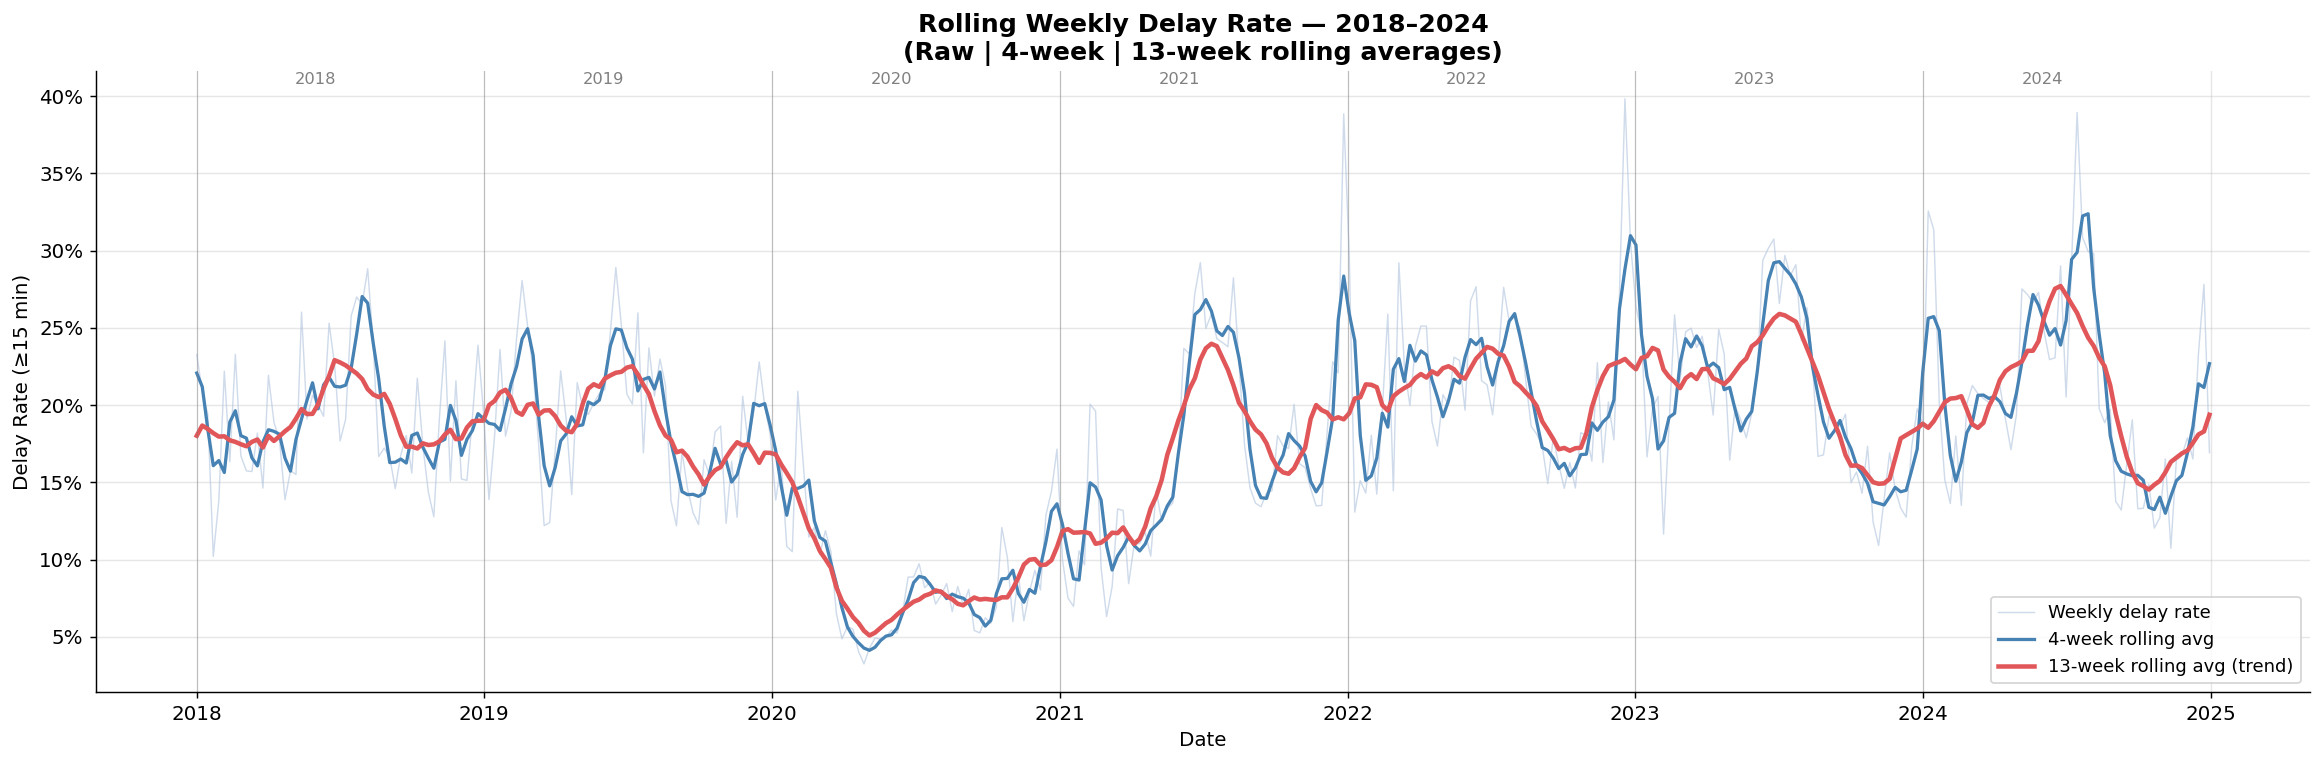

In [ ]:
# Compute weekly delay rate
weekly = (
    df.groupby(df['FlightDate'].dt.to_period('W'))['ArrDel15']
      .agg(delay_rate='mean', flights='count')
      .reset_index()
)
weekly['period_dt']     = weekly['FlightDate'].dt.start_time
weekly['rolling4w']     = weekly['delay_rate'].rolling(4, center=True, min_periods=2).mean()
weekly['rolling13w']    = weekly['delay_rate'].rolling(13, center=True, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(18, 6))

# Raw weekly
ax.plot(weekly['period_dt'], weekly['delay_rate'],
        color='lightsteelblue', linewidth=0.8, alpha=0.6, label='Weekly delay rate')
# 4-week rolling
ax.plot(weekly['period_dt'], weekly['rolling4w'],
        color='steelblue', linewidth=1.8, label='4-week rolling avg')
# 13-week (quarterly) rolling
ax.plot(weekly['period_dt'], weekly['rolling13w'],
        color='#e15759', linewidth=2.5, label='13-week rolling avg (trend)')

# Year separators
for yr in range(2018, 2025):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
               linestyle='-', linewidth=0.6, alpha=0.4)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[1] * 0.98,
            str(yr), ha='center', fontsize=9, color='gray')

pct_fmt(ax)
ax.set_title('Rolling Weekly Delay Rate — 2018–2024\n'
             '(Raw | 4-week | 13-week rolling averages)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Delay Rate (≥15 min)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig_14_rolling_trend.png', bbox_inches='tight')
plt.show()

In [ ]:
print('   The 13-week trend line clearly shows:')
print('   1. Stable ~20% (+-3) baseline pre-COVID (2018–2019)')
print('   2. Hard COVID plunge (2020 Q2)')
print('   3. Elevated post-COVID regime (2021–2024 settling again around ~20% but with very increased fluctuation)')
print('   ➡  Train-test split should probably be performed temporally, NOT randomly.')

   The 13-week trend line clearly shows:
   1. Stable ~20% (+-3) baseline pre-COVID (2018–2019)
   2. Hard COVID plunge (2020 Q2)
   3. Elevated post-COVID regime (2021–2024 settling again around ~20% but with very increased fluctuation)
   ➡  Train-test split should probably be performed temporally, NOT randomly.


---
## Section 14 — Seasonal Decomposition (STL)

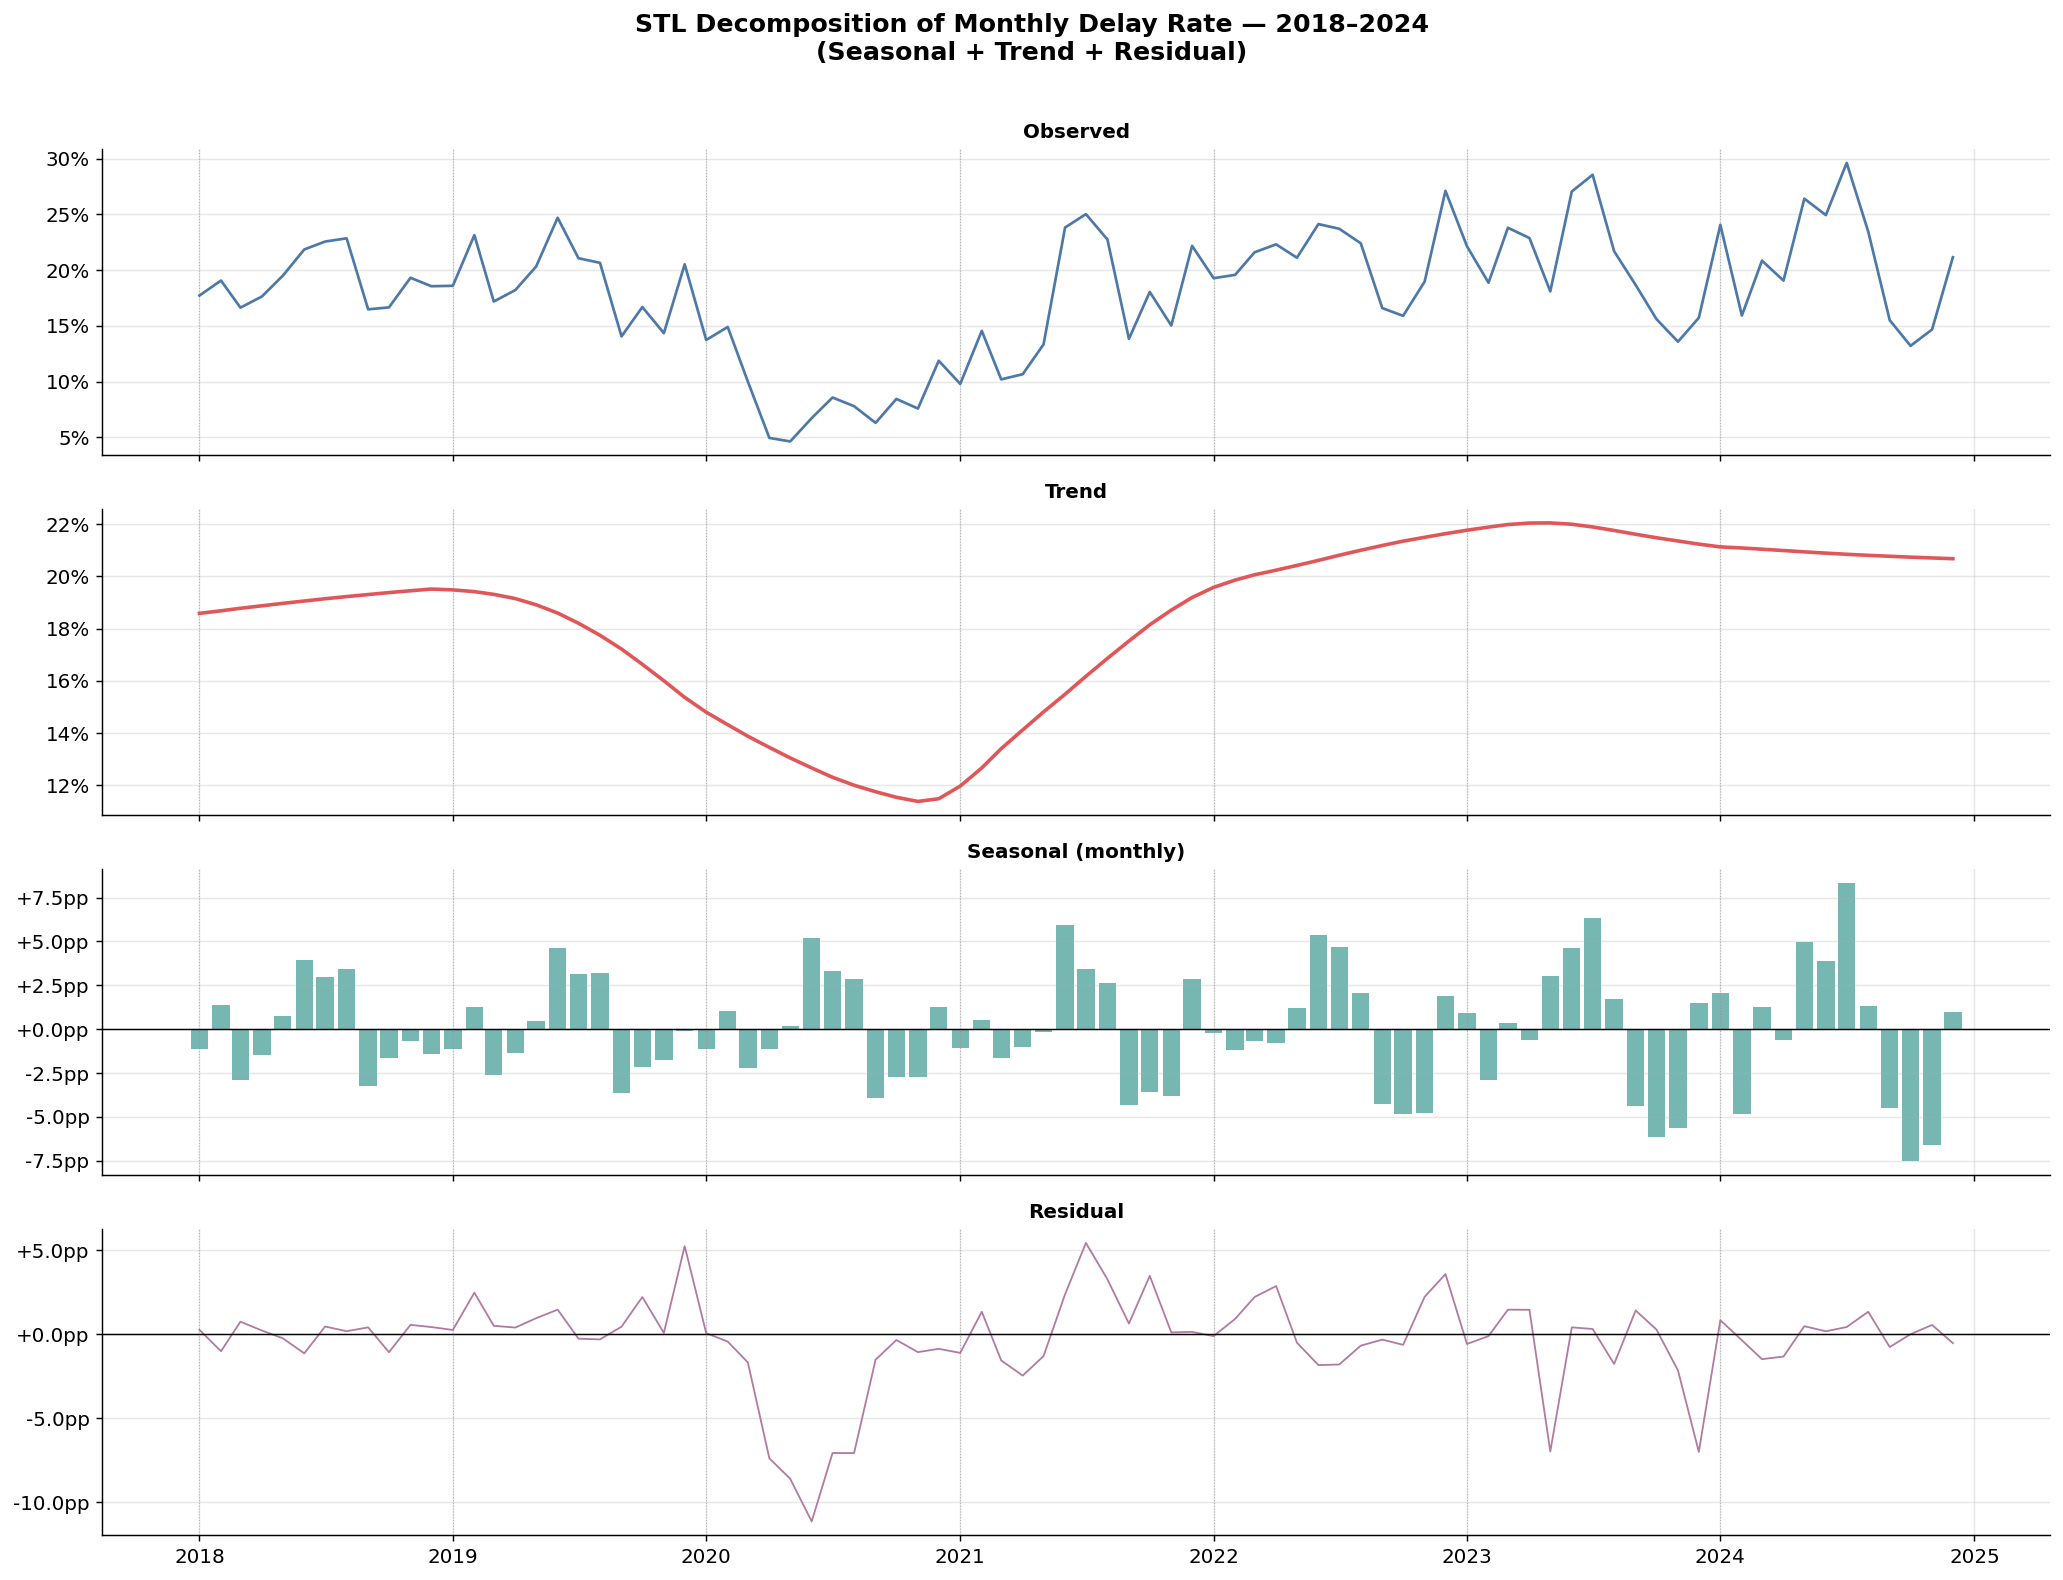

  Seasonal Strength (F_s): 0.590
   Values > 0.64 indicate strong seasonality (Wang et al. 2006).
   Average Monthly Seasonal Effect (percentage points vs trend):
   Jan: -0.24 pp  ↓
   Feb: -0.68 pp  ▓↓
   Mar: -1.21 pp  ▓▓↓
   Apr: -1.00 pp  ▓▓↓
   May: +1.48 pp  ▓▓↑
   Jun: +4.79 pp  ▓▓▓▓▓▓▓▓▓↑
   Jul: +4.60 pp  ▓▓▓▓▓▓▓▓▓↑
   Aug: +2.46 pp  ▓▓▓▓↑
   Sep: -4.05 pp  ▓▓▓▓▓▓▓▓↓
   Oct: -4.11 pp  ▓▓▓▓▓▓▓▓↓
   Nov: -3.71 pp  ▓▓▓▓▓▓▓↓
   Dec: +0.99 pp  ▓↑


In [ ]:
try:
    from statsmodels.tsa.seasonal import STL

    # Monthly time series
    ts = (
        df.groupby(['Year','Month'])['ArrDel15']
          .mean()
          .reset_index()
    )
    ts['period'] = pd.to_datetime(
        ts['Year'].astype(str) + '-' + ts['Month'].astype(str).str.zfill(2) + '-01')
    ts = ts.sort_values('period').set_index('period')['ArrDel15']
    ts.index = pd.DatetimeIndex(ts.index, freq='MS')

    # Fit STL (period=12 for monthly data)
    stl    = STL(ts, period=12, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

    axes[0].plot(ts.index, ts.values,          color='#4e79a7', linewidth=1.5)
    axes[0].set_title('Observed',              fontsize=11, fontweight='bold')
    pct_fmt(axes[0])

    axes[1].plot(ts.index, result.trend,       color='#e15759', linewidth=2)
    axes[1].set_title('Trend',                 fontsize=11, fontweight='bold')
    pct_fmt(axes[1])

    axes[2].bar(ts.index, result.seasonal,     color='#76b7b2', width=25)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Seasonal (monthly)',    fontsize=11, fontweight='bold')
    axes[2].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:+.1f}pp'))

    axes[3].plot(ts.index, result.resid,       color='#b07aa1', linewidth=1)
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].set_title('Residual',              fontsize=11, fontweight='bold')
    axes[3].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y*100:+.1f}pp'))

    for ax in axes:
        for yr in range(2018, 2025):
            ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                       linestyle=':', linewidth=0.6, alpha=0.5)

    fig.suptitle('STL Decomposition of Monthly Delay Rate — 2018–2024\n'
                 '(Seasonal + Trend + Residual)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig_15_stl_decomposition.png', bbox_inches='tight')
    plt.show()

    # Seasonal strength
    var_seasonal = np.var(result.seasonal)
    var_residual = np.var(result.resid)
    strength_s   = max(0, 1 - var_residual / (var_seasonal + var_residual))
    print(f'  Seasonal Strength (F_s): {strength_s:.3f}')
    print('   Values > 0.64 indicate strong seasonality (Wang et al. 2006).')

    # Month seasonal components
    seasonal_mean = (
        pd.Series(result.seasonal.values, index=ts.index)
          .groupby(lambda x: x.month)
          .mean()
    )
    print('   Average Monthly Seasonal Effect (percentage points vs trend):')
    for m, v in seasonal_mean.items():
        bar = '▓' * int(abs(v) * 200) + ('↑' if v > 0 else '↓')
        print(f'   {MONTH_NAMES[m]:>3}: {v*100:+.2f} pp  {bar}')

except ImportError:
    print('   statsmodels not found. Install with:  pip install statsmodels')
    print('   Then re-run this cell for the STL decomposition.')

---
## Section 15 — Correlation Matrix: Temporal & Weather Features vs ArrDel15

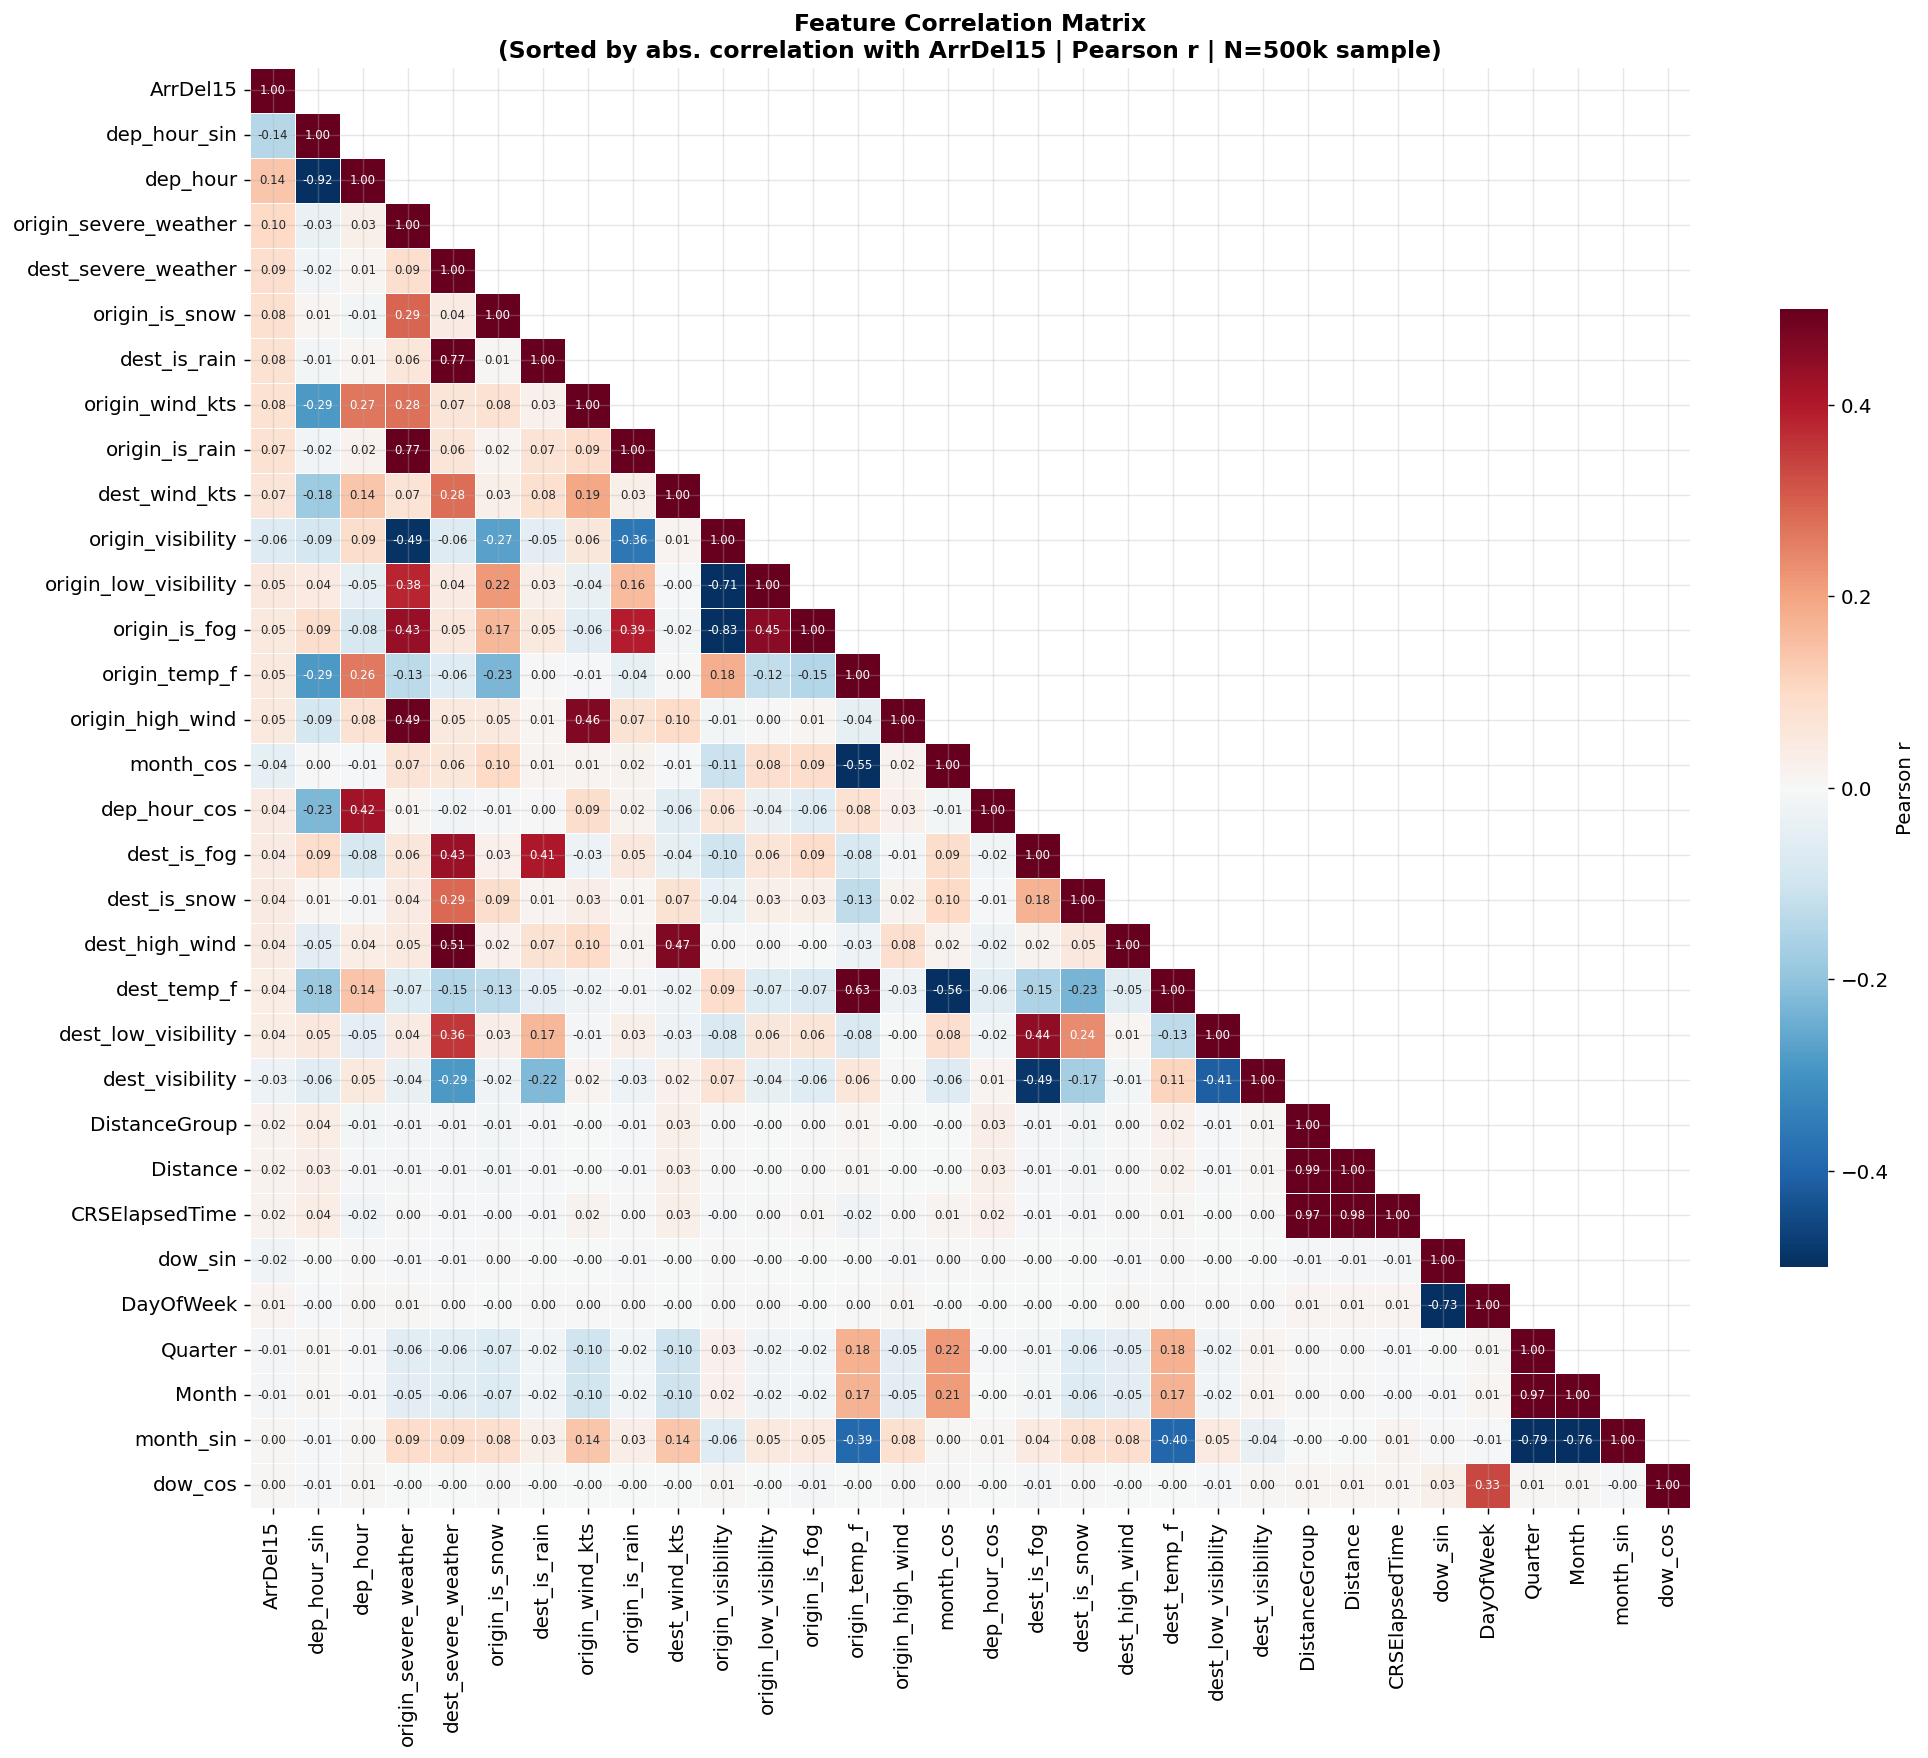

   Top 15 features by absolute Pearson correlation with ArrDel15:
─────────────────────────────────────────────
  dep_hour_sin                   +0.1425  ███████
  dep_hour                       +0.1391  ██████
  origin_severe_weather          +0.0988  ████
  dest_severe_weather            +0.0859  ████
  origin_is_snow                 +0.0791  ███
  dest_is_rain                   +0.0765  ███
  origin_wind_kts                +0.0760  ███
  origin_is_rain                 +0.0746  ███
  dest_wind_kts                  +0.0657  ███
  origin_visibility              +0.0648  ███
  origin_low_visibility          +0.0518  ██
  origin_is_fog                  +0.0506  ██
  origin_temp_f                  +0.0491  ██
  origin_high_wind               +0.0477  ██
  month_cos                      +0.0440  ██


In [ ]:
# Select numeric features available at T-2h
feature_cols = [
    'ArrDel15',
    # Temporal
    'Month', 'DayOfWeek', 'dep_hour', 'Quarter',
    # Flight
    'CRSElapsedTime', 'Distance', 'DistanceGroup',
    # Origin weather @ T-2h
    'origin_temp_f', 'origin_humidity', 'origin_wind_kts',
    'origin_visibility', 'origin_precip_in',
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    # Destination weather @ T-2h
    'dest_temp_f', 'dest_humidity', 'dest_wind_kts',
    'dest_visibility', 'dest_precip_in',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]
feature_cols_present = [c for c in feature_cols if c in df.columns]

# Sample 500k rows for speed
rng    = np.random.default_rng(42)
idx    = rng.choice(len(df), size=min(500_000, len(df)), replace=False)
sample = df.iloc[idx][feature_cols_present].copy()

# Encode dep_hour as sin/cos cyclical features
sample['dep_hour_sin'] = np.sin(2 * np.pi * sample['dep_hour'] / 24)
sample['dep_hour_cos'] = np.cos(2 * np.pi * sample['dep_hour'] / 24)
sample['month_sin']    = np.sin(2 * np.pi * sample['Month'] / 12)
sample['month_cos']    = np.cos(2 * np.pi * sample['Month'] / 12)
sample['dow_sin']      = np.sin(2 * np.pi * sample['DayOfWeek'] / 7)
sample['dow_cos']      = np.cos(2 * np.pi * sample['DayOfWeek'] / 7)

corr = sample.corr(method='pearson', numeric_only=True)

# Sort features by absolute correlation with target
target_corr = corr['ArrDel15'].drop('ArrDel15').abs().sort_values(ascending=False)
ordered_cols = ['ArrDel15'] + target_corr.index.tolist()
corr_sorted  = corr.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.zeros_like(corr_sorted, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle only

sns.heatmap(
    corr_sorted,
    mask     = mask,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdBu_r',
    center   = 0,
    vmin     = -0.5,
    vmax     = 0.5,
    linewidths = 0.3,
    ax       = ax,
    square   = True,
    cbar_kws = {'shrink': 0.6, 'label': 'Pearson r'},
    annot_kws= {'fontsize': 6.5},
)
ax.set_title(
    'Feature Correlation Matrix\n'
    '(Sorted by abs. correlation with ArrDel15 | Pearson r | N=500k sample)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_16_correlation_matrix.png', bbox_inches='tight')
plt.show()

print('   Top 15 features by absolute Pearson correlation with ArrDel15:')
print('─' * 45)
for feat, r in target_corr.head(15).items():
    bar = '█' * int(r * 50)
    print(f'  {feat:<30} {r:+.4f}  {bar}')